# Bayesian Optimization Competition

**After any structural change to this notebook, use Kernel > Restart and Run All** so the kernel runs cells in the correct order.

This notebook implements a systematic approach to optimizing 8 black-box functions using Bayesian optimization with surrogate models.

## Competition Overview

- **Objective**: Maximize 8 black-box functions with different dimensionalities (2D to 8D)
- **Constraint**: 1 query per function per week
- **Approach**: Use surrogate models to predict function behavior and select optimal next queries

## Notebook Structure

1. **Setup and Data Loading** - Initialize environment and load function data
2. **Surrogate Model Framework** - Modular framework for different surrogate models
3. **Acquisition Functions** - Functions to select next query points
4. **Function Analysis Dashboard** - Visualize and analyze each function
5. **Weekly Query Generator** - Generate recommended queries for submission
6. **Update Models with Results** - Add new observations and retrain
7. **Progress Tracking** - Monitor optimization progress over time

---
# SECTION 1: Setup and Data Loading
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from abc import ABC, abstractmethod
from typing import Tuple, Dict, List, Optional
import warnings
import re
import ast
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize

# Set random seed for reproducibility
np.random.seed(42)

# Configure warnings
warnings.filterwarnings('ignore')

# Configure matplotlib
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## FunctionData Class

In [2]:
class FunctionData:
    """Manages data for a single black-box function."""
    
    def __init__(self, function_id: int, data_dir: str = "../data"):
        self.function_id = function_id
        self.data_dir = Path(data_dir)
        self.function_dir = self.data_dir / f"function_{function_id}"
        
        # Load initial data
        self.inputs = np.load(self.function_dir / "initial_inputs.npy")
        self.outputs = np.load(self.function_dir / "initial_outputs.npy")
        
        # Store dimensions
        self.n_samples = len(self.outputs)
        self.n_dims = self.inputs.shape[1]
        
        # Track weekly updates
        self.week_number = 0
        self.history = []
        
    def add_observation(self, x: np.ndarray, y: float, week: Optional[int] = None):
        if week is None:
            self.week_number += 1
            week = self.week_number
        
        self.inputs = np.vstack([self.inputs, x.reshape(1, -1)])
        self.outputs = np.append(self.outputs, y)
        self.n_samples += 1
        self.history.append((week, x.copy(), y))
        
    def get_best(self) -> Tuple[np.ndarray, float]:
        best_idx = np.argmax(self.outputs)
        return self.inputs[best_idx], self.outputs[best_idx]
    
    def save_weekly_data(self, week: int):
        week_file_inputs = self.function_dir / f"week_{week}_inputs.npy"
        week_file_outputs = self.function_dir / f"week_{week}_outputs.npy"
        np.save(week_file_inputs, self.inputs)
        np.save(week_file_outputs, self.outputs)
        
    def get_summary(self) -> Dict:
        return {
            'function_id': self.function_id,
            'n_dims': self.n_dims,
            'n_samples': self.n_samples,
            'best_value': np.max(self.outputs),
            'mean_value': np.mean(self.outputs),
            'std_value': np.std(self.outputs)
        }
    
    def __repr__(self):
        best_x, best_y = self.get_best()
        return f"Function {self.function_id}: {self.n_dims}D, {self.n_samples} samples, best={best_y:.6f}"

print("✓ FunctionData class defined")

✓ FunctionData class defined


## Load All Functions

In [3]:
# Load all 8 functions
functions = {}
for i in range(1, 9):
    try:
        functions[i] = FunctionData(i)
        print(f"✓ Loaded {functions[i]}")
    except Exception as e:
        print(f"✗ Error loading function {i}: {e}")

print(f"\n✓ Successfully loaded {len(functions)} functions")

✓ Loaded Function 1: 2D, 10 samples, best=0.000000
✓ Loaded Function 2: 2D, 10 samples, best=0.611205
✓ Loaded Function 3: 3D, 15 samples, best=-0.034835
✓ Loaded Function 4: 4D, 30 samples, best=-4.025542
✓ Loaded Function 5: 4D, 20 samples, best=1088.859618
✓ Loaded Function 6: 5D, 20 samples, best=-0.714265
✓ Loaded Function 7: 6D, 30 samples, best=1.364968
✓ Loaded Function 8: 8D, 40 samples, best=9.598482

✓ Successfully loaded 8 functions


## Results Loading Functions

Functions to load weekly results from portal submissions.

In [4]:
def load_results(week_index: int = -1, results_dir: Optional[str] = None) -> Tuple[Dict[int, np.ndarray], Dict[int, float], int]:
    """
    Load results by week index from the latest available results directory.
    
    This simplified function uses index-based loading instead of directory names.
    Since the portal accumulates results (Week 2 files contain both Week 1 and Week 2 data),
    we can load from the latest directory and select by array index.
    
    Args:
        week_index: Week index (0=Week 1, 1=Week 2, -1=latest, -2=second-to-last, etc.)
        results_dir: Optional specific directory path. If None, auto-detects latest Week directory
    
    Returns:
        tuple: (inputs_dict, outputs_dict, actual_week_number)
            - inputs_dict: {function_id: numpy_array} for functions 1-8
            - outputs_dict: {function_id: float_value} for functions 1-8
            - actual_week_number: The actual week number (1, 2, 3, etc.)
    
    Examples:
        # Load latest week
        inputs, outputs, week_num = load_results()
        
        # Load Week 2 (index 1)
        inputs, outputs, week_num = load_results(week_index=1)
        
        # Load Week 1 (index 0)
        inputs, outputs, week_num = load_results(week_index=0)
    """
    # Auto-detect latest Week directory if not specified
    if results_dir is None:
        base_path = Path("..")
        week_dirs = sorted([d for d in base_path.glob("Week *") if d.is_dir()])
        if not week_dirs:
            raise FileNotFoundError("No Week directories found")
        results_dir = str(week_dirs[-1])  # Use latest
    
    results_path = Path(results_dir)
    if not results_path.exists():
        raise FileNotFoundError(f"Results directory not found: {results_path}")
    
    inputs_file = results_path / "inputs.txt"
    outputs_file = results_path / "outputs.txt"
    
    if not inputs_file.exists():
        raise FileNotFoundError(f"Inputs file not found: {inputs_file}")
    if not outputs_file.exists():
        raise FileNotFoundError(f"Outputs file not found: {outputs_file}")
    
    try:
        # Helper function to extract all list structures from a file
        def extract_all_lists(file_path):
            with open(file_path, 'r') as f:
                full_content = f.read()
            
            list_structures = []
            current_list = []
            
            for line in full_content.split('\n'):
                if line.strip().startswith('['):
                    if current_list:
                        list_structures.append('\n'.join(current_list))
                    current_list = [line]
                elif current_list:
                    current_list.append(line)
            
            if current_list:
                list_structures.append('\n'.join(current_list))
            
            return list_structures
        
        # Extract all weeks' data
        inputs_lists = extract_all_lists(inputs_file)
        outputs_lists = extract_all_lists(outputs_file)
        
        if not inputs_lists or not outputs_lists:
            raise ValueError("No valid data found in result files")
        
        # Handle negative indexing
        try:
            inputs_content = inputs_lists[week_index]
            outputs_content = outputs_lists[week_index]
            actual_week_num = week_index if week_index >= 0 else len(inputs_lists) + week_index
            actual_week_num += 1  # Convert to 1-indexed week number
        except IndexError:
            available = len(inputs_lists)
            raise IndexError(f"Week index {week_index} out of range. Available weeks: 0 to {available-1} (or -1 to -{available})")
        
        # Parse inputs
        inputs_content_clean = re.sub(r'array\(', '(', inputs_content)
        inputs_list = ast.literal_eval(inputs_content_clean)
        
        # Parse outputs
        outputs_content_clean = re.sub(r'np\.float64\(', '(', outputs_content)
        outputs_list = ast.literal_eval(outputs_content_clean)
        
        # Verify we have exactly 8 functions
        if len(inputs_list) != 8:
            raise ValueError(f"Expected 8 input arrays, got {len(inputs_list)}")
        if len(outputs_list) != 8:
            raise ValueError(f"Expected 8 output values, got {len(outputs_list)}")
        
        # Convert to dictionaries
        inputs_dict = {}
        outputs_dict = {}
        
        for func_id in range(1, 9):
            idx = func_id - 1
            
            if isinstance(inputs_list[idx], np.ndarray):
                inputs_dict[func_id] = inputs_list[idx]
            else:
                inputs_dict[func_id] = np.array(inputs_list[idx])
            
            output_val = outputs_list[idx]
            if hasattr(output_val, 'item'):
                outputs_dict[func_id] = float(output_val)
            else:
                outputs_dict[func_id] = float(output_val)
        
        print(f"✓ Successfully loaded Week {actual_week_num} results (index {week_index})")
        print(f"  Location: {results_path}")
        print(f"  Functions: 1-8")
        print(f"  Total weeks available: {len(inputs_lists)}")
        
        return inputs_dict, outputs_dict, actual_week_num
        
    except SyntaxError as e:
        raise ValueError(f"Failed to parse results files. Check file format. Error: {e}")
    except Exception as e:
        raise RuntimeError(f"Error loading results: {e}")

print("✓ load_results() function defined (simplified index-based loading)")

✓ load_results() function defined (simplified index-based loading)


## Historical Data Initialization

Functions to initialize FunctionData objects with all historical weekly results.

In [5]:
def initialize_from_history(functions_dict: Dict[int, FunctionData], 
                           week_indices: Optional[List[int]] = None,
                           results_dir: Optional[str] = None) -> Dict[int, Dict]:
    """
    Initialize functions with historical weekly results.
    
    CRITICAL: FunctionData objects only load initial_inputs.npy by default.
    This function loads historical weekly results from inputs.txt/outputs.txt
    and updates FunctionData objects with each week's observations sequentially.
    
    Args:
        functions_dict: Dictionary of FunctionData objects (keys 1-8)
        week_indices: List of week indices to load (e.g., [0, 1] for weeks 1-2)
                     If None, loads all available weeks
        results_dir: Directory containing inputs.txt/outputs.txt
                    If None, auto-detects latest Week directory
        
    Returns:
        dict: Summary of loaded data per week
              Format: {week_num: {'num_functions': int, 'functions': list}}
    
    Example:
        # Load all available weeks
        functions = {i: FunctionData(i) for i in range(1, 9)}
        summary = initialize_from_history(functions)
        
        # Load only specific weeks
        summary = initialize_from_history(functions, week_indices=[0, 1])
    """
    # Auto-detect latest Week directory if not specified
    if results_dir is None:
        base_path = Path("..")
        week_dirs = sorted([d for d in base_path.glob("Week *") if d.is_dir()])
        if not week_dirs:
            raise FileNotFoundError("No Week directories found")
        results_dir = str(week_dirs[-1])
    
    results_path = Path(results_dir)
    inputs_file = results_path / "inputs.txt"
    
    # Determine how many weeks are available
    with open(inputs_file, 'r') as f:
        content = f.read()
    num_available_weeks = content.count('\n[') + (1 if content.strip().startswith('[') else 0)
    
    # Determine which weeks to load
    if week_indices is None:
        week_indices = list(range(num_available_weeks))
    
    print("=" * 80)
    print("INITIALIZING FUNCTIONS FROM HISTORICAL DATA")
    print("=" * 80)
    print(f"Source: {results_path}")
    print(f"Available weeks: {num_available_weeks}")
    print(f"Loading weeks: {[i+1 for i in week_indices]} (indices {week_indices})")
    print()
    
    summary = {}
    
    for week_idx in week_indices:
        try:
            # Load this week's results
            inputs_dict, outputs_dict, week_num = load_results(
                week_index=week_idx, 
                results_dir=results_dir
            )
            
            # Update each function
            updated_functions = []
            for func_id in range(1, 9):
                if func_id in functions_dict and func_id in inputs_dict:
                    x = inputs_dict[func_id]
                    y = outputs_dict[func_id]
                    
                    # Add observation to function
                    functions_dict[func_id].add_observation(x, y, week=week_num)
                    updated_functions.append(func_id)
            
            summary[week_num] = {
                'num_functions': len(updated_functions),
                'functions': updated_functions
            }
            
            print(f"✓ Week {week_num}: Updated {len(updated_functions)} functions")
            
        except Exception as e:
            print(f"✗ Week index {week_idx}: Failed to load - {e}")
    
    print()
    print("=" * 80)
    print(f"✓ Initialization complete: {len(summary)} weeks loaded")
    print("=" * 80)
    
    # Display updated function states
    print("\nFunction States After Initialization:")
    print("-" * 80)
    for func_id in range(1, 9):
        if func_id in functions_dict:
            func = functions_dict[func_id]
            best_x, best_y = func.get_best()
            print(f"Function {func_id} ({func.n_dims}D): {func.n_samples} samples, best = {best_y:.6f}")
    print()
    
    return summary


print("✓ initialize_from_history() function defined")

✓ initialize_from_history() function defined


In [6]:
def initialize_all_weeks(functions_dict: Dict[int, FunctionData],
                        results_dir: Optional[str] = None) -> int:
    """
    Quick initialization with all available historical weeks.
    
    Convenience wrapper around initialize_from_history() that loads
    all available weeks from the latest Week directory.
    
    Args:
        functions_dict: Dictionary of FunctionData objects (keys 1-8)
        results_dir: Directory containing inputs.txt/outputs.txt
                    If None, auto-detects latest Week directory
    
    Returns:
        int: Number of weeks loaded
    
    Example:
        # Standard workflow after notebook restart
        functions = {i: FunctionData(i) for i in range(1, 9)}
        num_weeks = initialize_all_weeks(functions)
        print(f"Ready to analyze with {num_weeks} weeks of data")
    """
    summary = initialize_from_history(
        functions_dict=functions_dict,
        week_indices=None,  # Load all available
        results_dir=results_dir
    )
    return len(summary)


print("✓ initialize_all_weeks() convenience function defined")

✓ initialize_all_weeks() convenience function defined


## Initialize Functions with Historical Data

**Run this cell after loading functions to include all historical weekly results.**

## ⚠️ IMPORTANT: Initialize with Historical Data

**CRITICAL STEP:** After loading functions, you MUST initialize them with historical weekly results.

FunctionData objects only load `initial_inputs.npy` by default. To include Week 1, Week 2, etc. observations, run the initialization below.

In [7]:
# Initialize functions with all historical weekly results
# This loads Week 1, Week 2, etc. observations into the FunctionData objects
# (Uses initialize_from_history directly so this cell only depends on that and load_results.)
summary = initialize_from_history(functions_dict=functions, week_indices=None, results_dir=None)
num_weeks = len(summary)

assert num_weeks >= 1, "At least one week of results should load; check Week directory and outputs.txt."
print(f"\n✓ Loaded {num_weeks} weeks of historical data.")
print("Verification - sample counts per function (initial + weekly observations):")
for fid in range(1, 9):
    print(f"  Function {fid}: {functions[fid].n_samples} samples")
print("\n✓ Ready to analyze and generate queries with cumulative data!")

INITIALIZING FUNCTIONS FROM HISTORICAL DATA
Source: ../Week 3
Available weeks: 3
Loading weeks: [1, 2, 3] (indices [0, 1, 2])

✓ Successfully loaded Week 1 results (index 0)
  Location: ../Week 3
  Functions: 1-8
  Total weeks available: 3
✓ Week 1: Updated 8 functions
✓ Successfully loaded Week 2 results (index 1)
  Location: ../Week 3
  Functions: 1-8
  Total weeks available: 3
✓ Week 2: Updated 8 functions
✓ Successfully loaded Week 3 results (index 2)
  Location: ../Week 3
  Functions: 1-8
  Total weeks available: 3
✓ Week 3: Updated 8 functions

✓ Initialization complete: 3 weeks loaded

Function States After Initialization:
--------------------------------------------------------------------------------
Function 1 (2D): 13 samples, best = 0.000000
Function 2 (2D): 13 samples, best = 0.611205
Function 3 (3D): 18 samples, best = -0.022206
Function 4 (4D): 33 samples, best = 0.661171
Function 5 (4D): 23 samples, best = 5328.039449
Function 6 (5D): 23 samples, best = -0.565491
Functi

## Historical Initialization Usage Examples

Different patterns for loading historical data depending on your needs.

In [8]:
# EXAMPLE 1: Standard Workflow (Most Common)
# After notebook restart, load all available weeks

# Step 1: Load functions (only gets initial data)
# functions = {i: FunctionData(i) for i in range(1, 9)}

# Step 2: Initialize with all historical weeks (CRITICAL!)
# num_weeks = initialize_all_weeks(functions)
# print(f"Ready to work with {num_weeks} weeks of data")

# Now you're ready to:
# - Train surrogate models on complete data
# - Analyze performance across all weeks
# - Generate next week's queries

## Display Summary Statistics

## Section 5.2: Week 3 Strategy (Recovery & Balanced Exploration)

Based on Week 2 results, Week 3 implements:
- **Function 5 Recovery**: Search near Week 1's successful location
- **Function 1 Boundary Exploration**: Add explicit corner/edge sampling
- **Re-explore declined functions** (2, 3, 6, 7) with increased exploration
- **Continue success** for Functions 4 and 8

In [9]:
def optimize_acquisition_with_regional_focus(surrogate: "SurrogateModel", func_data: "FunctionData",
                                              acq_func: str = 'ucb', n_random: int = 1000,
                                              bound_margin: float = 0.02, expand_search: bool = True,
                                              focus_region: Optional[np.ndarray] = None,
                                              focus_radius: float = 0.15,
                                              **acq_params) -> Tuple[np.ndarray, float, float]:
    """
    Enhanced acquisition optimization with optional regional focus.
    
    Args:
        surrogate: Fitted surrogate model
        func_data: Function data object
        acq_func: Acquisition function ('ucb', 'ei', 'pi')
        n_random: Number of random candidates
        bound_margin: Margin from boundaries [0, 1)
        expand_search: Whether to expand beyond observed data bounds
        focus_region: Optional center point for regional search (e.g., previous best location)
        focus_radius: Radius around focus_region to sample more densely
        **acq_params: Additional acquisition function parameters
    
    Returns:
        (next_query, predicted_mean, predicted_std)
    """
    n_dims = func_data.n_dims
    n_refine = 10
    
    # Determine bounds
    if expand_search:
        bounds = [(bound_margin, 1.0 - bound_margin) for _ in range(n_dims)]
    else:
        X_min = func_data.inputs.min(axis=0) - 0.1
        X_max = func_data.inputs.max(axis=0) + 0.1
        X_min = np.clip(X_min, bound_margin, 1.0 - bound_margin)
        X_max = np.clip(X_max, bound_margin, 1.0 - bound_margin)
        bounds = list(zip(X_min, X_max))
    
    # Stage 1: Generate candidate points
    X_random = np.random.uniform(
        low=[b[0] for b in bounds],
        high=[b[1] for b in bounds],
        size=(n_random, n_dims)
    )
    
    # Add regional focus samples if specified (for Function 5 recovery)
    if focus_region is not None:
        n_focus = n_random // 3  # 1/3 of samples near focus region
        noise = np.random.normal(0, focus_radius, size=(n_focus, n_dims))
        X_focus = focus_region + noise
        X_focus = np.clip(X_focus, bound_margin, 1.0 - bound_margin)
        X_random = np.vstack([X_random, X_focus])
    
    # Add samples near current best (exploitation)
    best_x, _ = func_data.get_best()
    n_near_best = n_random // 5
    X_near_best = best_x + np.random.normal(0, 0.1, size=(n_near_best, n_dims))
    X_near_best = np.clip(X_near_best, bound_margin, 1.0 - bound_margin)
    X_random = np.vstack([X_random, X_near_best])
    
    # Predict at all candidates
    mean, std = surrogate.predict(X_random)
    
    # Calculate acquisition values
    if acq_func == 'ucb':
        acq_values = AcquisitionFunction.ucb(mean, std, beta=acq_params.get('beta', 2.0))
    elif acq_func == 'ei':
        _, y_best = func_data.get_best()
        acq_values = AcquisitionFunction.ei(mean, std, y_best, xi=acq_params.get('xi', 0.01))
    elif acq_func == 'pi':
        _, y_best = func_data.get_best()
        acq_values = AcquisitionFunction.pi(mean, std, y_best, xi=acq_params.get('xi', 0.01))
    else:
        raise ValueError(f"Unknown acquisition function: {acq_func}")
    
    # Stage 2: Local refinement from top candidates
    best_candidates_idx = np.argsort(acq_values)[-n_refine:]
    best_candidate = X_random[best_candidates_idx[-1]].copy()
    best_acq_value = -np.inf
    
    for idx in best_candidates_idx:
        x0 = X_random[idx]
        
        def objective(x):
            x = np.clip(x, bound_margin, 1.0 - bound_margin)
            x = x.reshape(1, -1)
            m, s = surrogate.predict(x)
            if acq_func == 'ucb':
                return -AcquisitionFunction.ucb(m, s, beta=acq_params.get('beta', 2.0))[0]
            elif acq_func == 'ei':
                _, y_best = func_data.get_best()
                return -AcquisitionFunction.ei(m, s, y_best, xi=acq_params.get('xi', 0.01))[0]
            else:
                _, y_best = func_data.get_best()
                return -AcquisitionFunction.pi(m, s, y_best, xi=acq_params.get('xi', 0.01))[0]
        
        result = minimize(objective, x0, method='L-BFGS-B', bounds=bounds)
        
        if -result.fun > best_acq_value:
            best_acq_value = -result.fun
            best_candidate = np.clip(result.x, bound_margin, 1.0 - bound_margin)
    
    # Get predictions at best candidate
    pred_mean, pred_std = surrogate.predict(best_candidate.reshape(1, -1))
    
    return best_candidate, pred_mean[0], pred_std[0]


def add_boundary_samples_2d(n_dims: int, n_samples: int = 8, margin: float = 0.02) -> np.ndarray:
    """
    Generate explicit boundary/corner samples for 2D functions.
    Helps with Function 1's "dead zone" problem.
    
    Args:
        n_dims: Dimensionality (should be 2 for this use case)
        n_samples: Number of boundary samples to generate
        margin: Distance from actual boundary
    
    Returns:
        Array of boundary samples (n_samples x n_dims)
    """
    if n_dims != 2:
        # For higher dimensions, sample random corners
        samples = []
        for _ in range(n_samples):
            corner = np.random.choice([margin, 1.0 - margin], size=n_dims)
            samples.append(corner)
        return np.array(samples)
    
    # For 2D: corners and edge midpoints
    corners = [
        [margin, margin],           # Bottom-left
        [margin, 1.0 - margin],     # Top-left
        [1.0 - margin, margin],     # Bottom-right
        [1.0 - margin, 1.0 - margin], # Top-right
    ]
    
    edges = [
        [margin, 0.5],              # Left edge middle
        [1.0 - margin, 0.5],        # Right edge middle
        [0.5, margin],              # Bottom edge middle
        [0.5, 1.0 - margin],        # Top edge middle
    ]
    
    return np.array(corners + edges)


print("✓ Regional focus and boundary sampling functions defined")

✓ Regional focus and boundary sampling functions defined


---
# SECTION 2: Surrogate Model Framework
---

In [10]:
class SurrogateModel(ABC):
    """Abstract base class for surrogate models."""
    
    @abstractmethod
    def fit(self, X: np.ndarray, y: np.ndarray):
        pass
    
    @abstractmethod
    def predict(self, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        pass
    
    @abstractmethod
    def get_name(self) -> str:
        pass

print("✓ SurrogateModel base class defined")

✓ SurrogateModel base class defined


## Gaussian Process Surrogate

In [11]:
class GPSurrogate(SurrogateModel):
    """Gaussian Process surrogate model with RBF kernel. Supports ARD for per-dimension length scales."""
    
    def __init__(self, length_scale: float = 1.0, length_scale_bounds: Tuple = (1e-2, 1e2),
                 noise: float = 1e-5, optimize: bool = True, use_ard: bool = False):
        self.length_scale = length_scale
        self.length_scale_bounds = length_scale_bounds
        self.noise = noise
        self.optimize = optimize
        self.use_ard = use_ard
        
        if not use_ard:
            kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale, length_scale_bounds)
            self.model = GaussianProcessRegressor(
                kernel=kernel,
                alpha=noise,
                n_restarts_optimizer=10 if optimize else 0,
                normalize_y=True,
                random_state=42
            )
        else:
            self.model = None  # Built in fit() when n_dims is known
        
        self.is_fitted = False
        
    def fit(self, X: np.ndarray, y: np.ndarray):
        if self.use_ard:
            n_dims = X.shape[1]
            # ARD: one length scale per dimension (learned)
            kernel = C(1.0, (1e-3, 1e3)) * RBF(
                length_scale=np.ones(n_dims) * self.length_scale,
                length_scale_bounds=self.length_scale_bounds
            )
            self.model = GaussianProcessRegressor(
                kernel=kernel,
                alpha=self.noise,
                n_restarts_optimizer=10 if self.optimize else 0,
                normalize_y=True,
                random_state=42
            )
        self.model.fit(X, y)
        self.is_fitted = True
        
    def predict(self, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if not self.is_fitted:
            raise ValueError("Model must be fitted before prediction")
        mean, std = self.model.predict(X, return_std=True)
        return mean, std
    
    def get_name(self) -> str:
        if self.use_ard and self.is_fitted:
            return "GP-RBF-ARD"
        return f"GP-RBF (ls={self.length_scale:.3f})"
    
    def get_length_scales(self) -> Optional[np.ndarray]:
        """Return learned length scales (per-dimension if use_ard=True). Only valid after fit."""
        if not self.is_fitted or self.model.kernel_ is None:
            return None
        # RBF kernel stores length_scale in the second part of the product
        k = self.model.kernel_
        if hasattr(k, "k2") and hasattr(k.k2, "length_scale"):
            return np.atleast_1d(k.k2.length_scale)
        return None

print("✓ GPSurrogate class defined")

✓ GPSurrogate class defined


In [12]:
def gp_mean_gradient(surrogate: "GPSurrogate", x: np.ndarray, eps: float = 1e-5,
                     bounds: Optional[Tuple[float, float]] = (0.0, 1.0)) -> np.ndarray:
    """
    Compute gradient of the GP posterior mean at x: nabla mu(x).
    Uses central finite differences. Useful for steepest-ascent direction at best-known points.
    
    Args:
        surrogate: Fitted GPSurrogate (must be fitted).
        x: Point at which to compute gradient (1d array).
        eps: Finite-difference step.
        bounds: (low, high) to clip x +/- eps.
    
    Returns:
        grad: Array of shape (n_dims,) with partial derivatives d(mu)/d(x_j).
    """
    x = np.asarray(x).ravel()
    n = x.size
    grad = np.zeros(n)
    low, high = bounds[0], bounds[1]
    for j in range(n):
        e = np.zeros(n)
        e[j] = 1.0
        x_plus = np.clip(x + eps * e, low, high - 1e-8)
        x_minus = np.clip(x - eps * e, low, high - 1e-8)
        mu_plus = surrogate.predict(x_plus.reshape(1, -1))[0][0]
        mu_minus = surrogate.predict(x_minus.reshape(1, -1))[0][0]
        grad[j] = (mu_plus - mu_minus) / (2.0 * eps)
    return grad


print("✓ gp_mean_gradient() utility defined")

✓ gp_mean_gradient() utility defined


---
# SECTION 3: Acquisition Functions
---

In [13]:
class AcquisitionFunction:
    """Collection of acquisition functions for Bayesian optimization."""
    
    @staticmethod
    def ucb(mean: np.ndarray, std: np.ndarray, beta: float = 2.0) -> np.ndarray:
        """Upper Confidence Bound: UCB = mean + beta * std"""
        return mean + beta * std
    
    @staticmethod
    def ei(mean: np.ndarray, std: np.ndarray, y_best: float, xi: float = 0.01) -> np.ndarray:
        """Expected Improvement"""
        std = np.maximum(std, 1e-9)
        z = (mean - y_best - xi) / std
        ei_value = (mean - y_best - xi) * norm.cdf(z) + std * norm.pdf(z)
        return ei_value
    
    @staticmethod
    def pi(mean: np.ndarray, std: np.ndarray, y_best: float, xi: float = 0.01) -> np.ndarray:
        """Probability of Improvement"""
        std = np.maximum(std, 1e-9)
        z = (mean - y_best - xi) / std
        pi_value = norm.cdf(z)
        return pi_value

print("✓ Acquisition functions defined (UCB, EI, PI)")

✓ Acquisition functions defined (UCB, EI, PI)


## Optimize Acquisition Function

In [14]:
def optimize_acquisition(surrogate: SurrogateModel, func_data: FunctionData,
                         acq_func: str = 'ucb', n_random: int = 1000,
                         n_refine: int = 10, **acq_params) -> np.ndarray:
    """Find the point that maximizes the acquisition function."""
    # Normalize acquisition function name to lowercase for case-insensitive comparison
    acq_func = acq_func.lower()
    
    n_dims = func_data.n_dims
    
    # Determine bounds from existing data
    bounds = []
    for i in range(n_dims):
        x_min, x_max = func_data.inputs[:, i].min(), func_data.inputs[:, i].max()
        margin = (x_max - x_min) * 0.1
        bounds.append((max(0, x_min - margin), min(1, x_max + margin)))
    
    # Stage 1: Random sampling
    X_random = np.random.uniform(0, 1, size=(n_random, n_dims))
    for i in range(n_dims):
        X_random[:, i] = X_random[:, i] * (bounds[i][1] - bounds[i][0]) + bounds[i][0]
    
    mean, std = surrogate.predict(X_random)
    
    # Calculate acquisition values
    if acq_func == 'ucb':
        acq_values = AcquisitionFunction.ucb(mean, std, beta=acq_params.get('beta', 2.0))
    elif acq_func == 'ei':
        _, y_best = func_data.get_best()
        acq_values = AcquisitionFunction.ei(mean, std, y_best, xi=acq_params.get('xi', 0.01))
    elif acq_func == 'pi':
        _, y_best = func_data.get_best()
        acq_values = AcquisitionFunction.pi(mean, std, y_best, xi=acq_params.get('xi', 0.01))
    else:
        raise ValueError(f"Unknown acquisition function: {acq_func}")
    
    # Stage 2: Local refinement
    best_candidates_idx = np.argsort(acq_values)[-n_refine:]
    best_candidate = None
    best_acq_value = -np.inf
    
    for idx in best_candidates_idx:
        x0 = X_random[idx]
        
        def objective(x):
            x = x.reshape(1, -1)
            mean, std = surrogate.predict(x)
            if acq_func == 'ucb':
                return -AcquisitionFunction.ucb(mean, std, beta=acq_params.get('beta', 2.0))[0]
            elif acq_func == 'ei':
                _, y_best = func_data.get_best()
                return -AcquisitionFunction.ei(mean, std, y_best, xi=acq_params.get('xi', 0.01))[0]
            else:
                _, y_best = func_data.get_best()
                return -AcquisitionFunction.pi(mean, std, y_best, xi=acq_params.get('xi', 0.01))[0]
        
        result = minimize(objective, x0, method='L-BFGS-B', bounds=bounds)
        
        if -result.fun > best_acq_value:
            best_acq_value = -result.fun
            best_candidate = result.x
    
    return best_candidate

print("✓ Acquisition optimization function defined")

✓ Acquisition optimization function defined


## Enhanced Acquisition Optimization (with Boundary Enforcement)

This improved version prevents queries from hitting extreme boundary values (0 or 1), which often lead to poor results, especially for high-dimensional functions like Function 8.

In [15]:
def optimize_acquisition_enhanced(surrogate: SurrogateModel, func_data: FunctionData,
                                   acq_func: str = 'ucb', n_random: int = 1000,
                                   n_refine: int = 10, 
                                   bound_margin: float = 0.02,  # Stay away from 0 and 1
                                   expand_search: bool = True,  # Search full [0,1] space
                                   **acq_params) -> Tuple[np.ndarray, float, float]:
    """
    Enhanced acquisition optimization with boundary enforcement.
    
    Args:
        surrogate: Fitted surrogate model
        func_data: Function data object
        acq_func: Acquisition function ('ucb', 'ei', 'pi')
        n_random: Number of random samples for global search
        n_refine: Number of local refinement starts
        bound_margin: Minimum distance from 0 and 1 (prevents boundary values)
        expand_search: If True, search full [0,1] space; if False, use data-driven bounds
        **acq_params: Additional parameters for acquisition function
    
    Returns:
        Tuple of (best_point, predicted_mean, predicted_std)
    """
    # Normalize acquisition function name to lowercase for case-insensitive comparison
    acq_func = acq_func.lower()
    
    n_dims = func_data.n_dims
    
    # Scale n_random with dimensionality for better coverage
    n_random_scaled = n_random * (1 + n_dims // 4)  # More samples for higher dims
    n_random_scaled = min(n_random_scaled, 6000)  # Cap to avoid very long runs in high-D (e.g. 8D)
    
    # Determine bounds - enforce margin from edges
    if expand_search:
        # Search full space but avoid edges
        bounds = [(bound_margin, 1.0 - bound_margin) for _ in range(n_dims)]
    else:
        # Data-driven bounds with margin
        bounds = []
        for i in range(n_dims):
            x_min, x_max = func_data.inputs[:, i].min(), func_data.inputs[:, i].max()
            margin = (x_max - x_min) * 0.2  # 20% expansion
            lower = max(bound_margin, x_min - margin)
            upper = min(1.0 - bound_margin, x_max + margin)
            bounds.append((lower, upper))
    
    # Stage 1: Random sampling with stratified approach
    X_random = np.zeros((n_random_scaled, n_dims))
    for i in range(n_dims):
        X_random[:, i] = np.random.uniform(bounds[i][0], bounds[i][1], n_random_scaled)
    
    # Add some samples near the current best point (exploitation)
    best_x, _ = func_data.get_best()
    n_near_best = n_random_scaled // 5
    X_near_best = best_x + np.random.normal(0, 0.1, size=(n_near_best, n_dims))
    X_near_best = np.clip(X_near_best, bound_margin, 1.0 - bound_margin)
    X_random = np.vstack([X_random, X_near_best])
    
    mean, std = surrogate.predict(X_random)
    
    # Calculate acquisition values
    if acq_func == 'ucb':
        acq_values = AcquisitionFunction.ucb(mean, std, beta=acq_params.get('beta', 2.0))
    elif acq_func == 'ei':
        _, y_best = func_data.get_best()
        acq_values = AcquisitionFunction.ei(mean, std, y_best, xi=acq_params.get('xi', 0.01))
    elif acq_func == 'pi':
        _, y_best = func_data.get_best()
        acq_values = AcquisitionFunction.pi(mean, std, y_best, xi=acq_params.get('xi', 0.01))
    else:
        raise ValueError(f"Unknown acquisition function: {acq_func}")
    
    # Stage 2: Local refinement from top candidates
    best_candidates_idx = np.argsort(acq_values)[-n_refine:]
    # Initialize with best random candidate
    best_candidate = X_random[best_candidates_idx[-1]].copy()
    best_acq_value = -np.inf
    
    for idx in best_candidates_idx:
        x0 = X_random[idx]
        
        def objective(x):
            # Ensure x stays within bounds
            x = np.clip(x, bound_margin, 1.0 - bound_margin)
            x = x.reshape(1, -1)
            m, s = surrogate.predict(x)
            if acq_func == 'ucb':
                return -AcquisitionFunction.ucb(m, s, beta=acq_params.get('beta', 2.0))[0]
            elif acq_func == 'ei':
                _, y_best = func_data.get_best()
                return -AcquisitionFunction.ei(m, s, y_best, xi=acq_params.get('xi', 0.01))[0]
            else:
                _, y_best = func_data.get_best()
                return -AcquisitionFunction.pi(m, s, y_best, xi=acq_params.get('xi', 0.01))[0]
        
        result = minimize(objective, x0, method='L-BFGS-B', bounds=bounds)
        
        if -result.fun > best_acq_value:
            best_acq_value = -result.fun
            best_candidate = np.clip(result.x, bound_margin, 1.0 - bound_margin)
    
    # Get predictions at best candidate
    pred_mean, pred_std = surrogate.predict(best_candidate.reshape(1, -1))
    
    return best_candidate, pred_mean[0], pred_std[0]

print("✓ Enhanced acquisition optimization defined (with boundary enforcement)")

✓ Enhanced acquisition optimization defined (with boundary enforcement)


## 2D Function Surface Visualization

For Functions 1 and 2 (2D), visualize the GP prediction surface to understand where peaks might be located. This helps identify promising regions to explore.

In [16]:
def visualize_2d_surface(func_id: int, surrogate: Optional[SurrogateModel] = None, 
                         show_acquisition: bool = True, acq_func: str = 'ucb',
                         resolution: int = 50, **acq_params):
    """
    Visualize GP prediction surface for 2D functions.
    
    Args:
        func_id: Function ID (should be 1 or 2 for 2D functions)
        surrogate: Fitted surrogate model (creates new one if None)
        show_acquisition: Whether to also plot acquisition function
        acq_func: Acquisition function for visualization
        resolution: Grid resolution for surface
        **acq_params: Parameters for acquisition function
    """
    func_data = functions[func_id]
    
    if func_data.n_dims != 2:
        print(f"⚠ Function {func_id} is {func_data.n_dims}D, not 2D. Cannot visualize surface.")
        return
    
    # Create and fit surrogate if not provided
    if surrogate is None:
        surrogate = GPSurrogate(length_scale=0.5, optimize=True)
        surrogate.fit(func_data.inputs, func_data.outputs)
    
    # Create grid
    x0 = np.linspace(0.02, 0.98, resolution)  # Avoid boundaries
    x1 = np.linspace(0.02, 0.98, resolution)
    X0, X1 = np.meshgrid(x0, x1)
    X_grid = np.column_stack([X0.ravel(), X1.ravel()])
    
    # Predict
    mean, std = surrogate.predict(X_grid)
    mean_grid = mean.reshape(resolution, resolution)
    std_grid = std.reshape(resolution, resolution)
    
    # Calculate acquisition function and create plots
    if show_acquisition:
        # Calculate acquisition values
        if acq_func == 'ucb':
            acq_values = AcquisitionFunction.ucb(mean, std, beta=acq_params.get('beta', 2.0))
        elif acq_func == 'ei':
            _, y_best = func_data.get_best()
            acq_values = AcquisitionFunction.ei(mean, std, y_best, xi=acq_params.get('xi', 0.01))
        else:
            _, y_best = func_data.get_best()
            acq_values = AcquisitionFunction.pi(mean, std, y_best, xi=acq_params.get('xi', 0.01))
        acq_grid = acq_values.reshape(resolution, resolution)
        max_idx = np.argmax(acq_values)
        max_x = X_grid[max_idx]
    
    # Create figure
    n_cols = 3 if show_acquisition else 2
    fig, axes = plt.subplots(1, n_cols, figsize=(6*n_cols, 5))
    
    # Plot 1: Mean prediction
    ax1 = axes[0]
    c1 = ax1.contourf(X0, X1, mean_grid, levels=30, cmap='viridis')
    ax1.scatter(func_data.inputs[:, 0], func_data.inputs[:, 1], 
                c='red', s=100, edgecolors='white', linewidths=2, zorder=5,
                label='Observations')
    best_x, best_y = func_data.get_best()
    ax1.scatter(best_x[0], best_x[1], c='gold', s=200, marker='*', 
                edgecolors='black', linewidths=2, zorder=6, label=f'Best (y={best_y:.4f})')
    ax1.set_xlabel('x₀')
    ax1.set_ylabel('x₁')
    ax1.set_title(f'Function {func_id}: GP Mean Prediction')
    plt.colorbar(c1, ax=ax1, label='Predicted Value')
    ax1.legend(loc='upper right', fontsize=8)
    
    # Plot 2: Uncertainty (std)
    ax2 = axes[1]
    c2 = ax2.contourf(X0, X1, std_grid, levels=30, cmap='plasma')
    ax2.scatter(func_data.inputs[:, 0], func_data.inputs[:, 1], 
                c='white', s=80, edgecolors='black', linewidths=1, zorder=5)
    ax2.set_xlabel('x₀')
    ax2.set_ylabel('x₁')
    ax2.set_title(f'Function {func_id}: GP Uncertainty (σ)')
    plt.colorbar(c2, ax=ax2, label='Standard Deviation')
    
    # Plot 3: Acquisition function (if enabled)
    if show_acquisition:
        ax3 = axes[2]
        c3 = ax3.contourf(X0, X1, acq_grid, levels=30, cmap='RdYlGn')
        ax3.scatter(func_data.inputs[:, 0], func_data.inputs[:, 1], 
                    c='blue', s=80, edgecolors='white', linewidths=1, zorder=5)
        
        # Find and mark the maximum of acquisition function
        max_idx = np.argmax(acq_values)
        max_x = X_grid[max_idx]
        ax3.scatter(max_x[0], max_x[1], c='red', s=300, marker='*', 
                    edgecolors='black', linewidths=2, zorder=6, label='Next Query')
        
        ax3.set_xlabel('x₀')
        ax3.set_ylabel('x₁')
        ax3.set_title(f'Function {func_id}: {acq_func.upper()} Acquisition')
        plt.colorbar(c3, ax=ax3, label='Acquisition Value')
        ax3.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # Print insights
    print(f"\n{'='*60}")
    print(f"Function {func_id} Surface Analysis")
    print(f"{'='*60}")
    print(f"Mean prediction range: [{mean.min():.4f}, {mean.max():.4f}]")
    print(f"Uncertainty range: [{std.min():.4f}, {std.max():.4f}]")
    print(f"Best observed: y = {best_y:.6f} at x = {best_x}")
    if show_acquisition:
        print(f"Suggested next query: {max_x}")
        pred_m, pred_s = surrogate.predict(max_x.reshape(1, -1))
        print(f"  Predicted: mean={pred_m[0]:.4f}, std={pred_s[0]:.4f}")
    print(f"{'='*60}")

print("✓ 2D surface visualization function defined")

✓ 2D surface visualization function defined


## Example: Visualize Function 1 and 2 Surfaces

Run these to understand where the GP thinks peaks might be located.

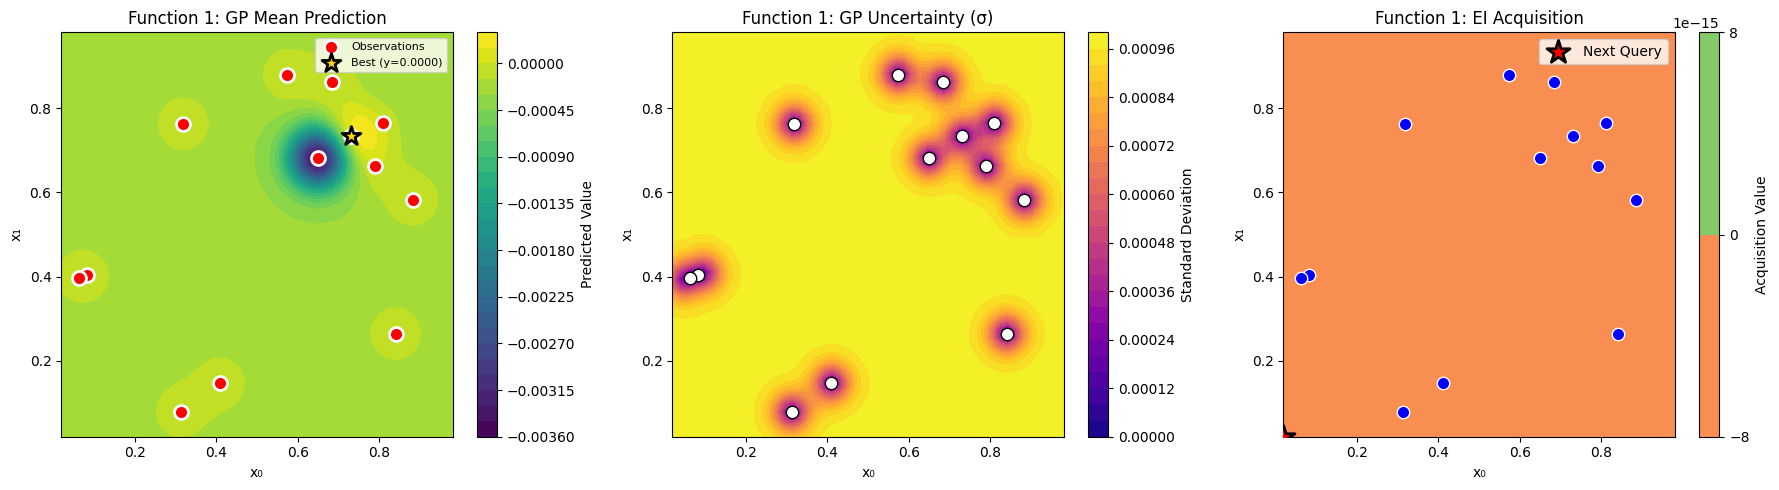


Function 1 Surface Analysis
Mean prediction range: [-0.0036, 0.0003]
Uncertainty range: [0.0000, 0.0010]
Best observed: y = 0.000000 at x = [0.73102363 0.73299988]
Suggested next query: [0.02 0.02]
  Predicted: mean=-0.0003, std=0.0010


In [17]:
# Visualize Function 1 (Contamination Detection)
# Uses EI with high exploration since Week 1 showed no improvement
visualize_2d_surface(1, acq_func='ei', xi=0.1)

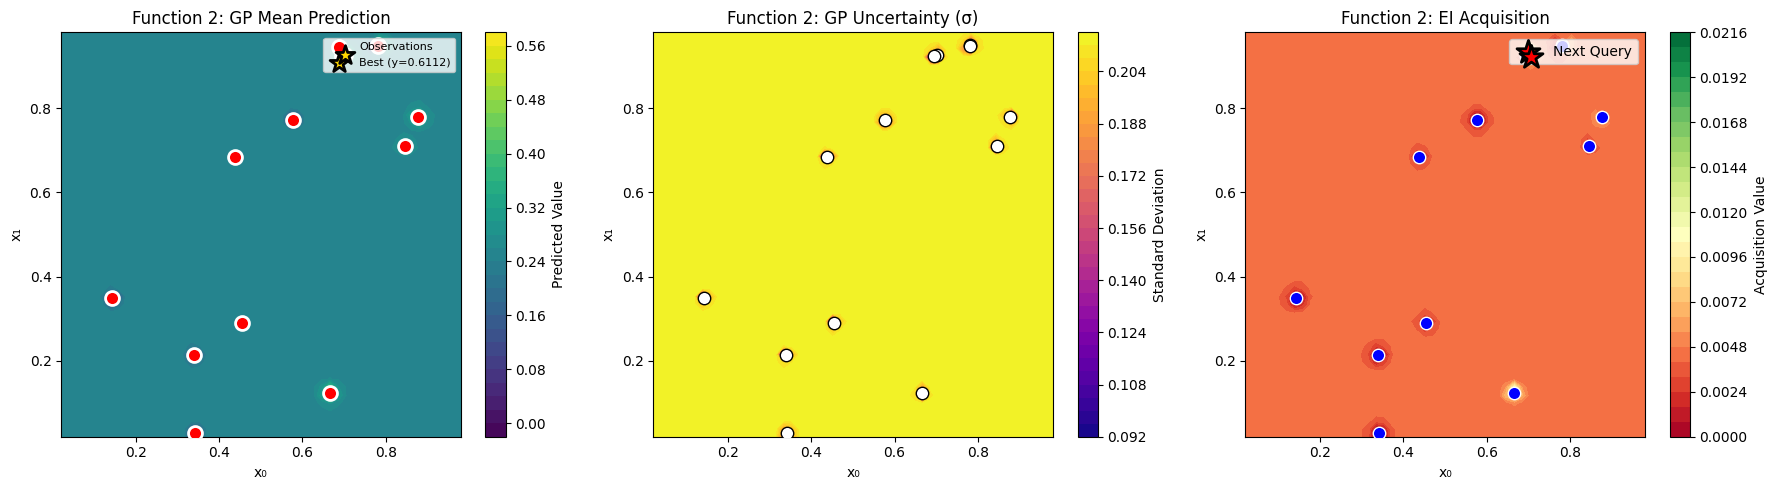


Function 2 Surface Analysis
Mean prediction range: [-0.0143, 0.5607]
Uncertainty range: [0.0957, 0.2135]
Best observed: y = 0.611205 at x = [0.70263656 0.9265642 ]
Suggested next query: [0.70571429 0.92122449]
  Predicted: mean=0.5607, std=0.1082


In [18]:
# Visualize Function 2 (Noisy ML Model)
# Uses EI with low exploration to exploit near known best region
visualize_2d_surface(2, acq_func='ei', xi=0.005)

## Prediction Tracking System

Track GP predictions vs actual results to understand model accuracy and improve strategy over time.

In [19]:
class PredictionTracker:
    """
    Track predictions vs actual results to analyze surrogate model accuracy.
    Helps identify when to adjust strategies.
    """
    
    def __init__(self):
        self.predictions = {}  # {week: {func_id: {'query': x, 'pred_mean': m, 'pred_std': s, 'actual': y}}}
        
    def record_prediction(self, week: int, func_id: int, query: np.ndarray, 
                         pred_mean: float, pred_std: float):
        """Record a prediction before submission."""
        if week not in self.predictions:
            self.predictions[week] = {}
        
        self.predictions[week][func_id] = {
            'query': query.copy(),
            'pred_mean': pred_mean,
            'pred_std': pred_std,
            'actual': None,
            'error': None,
            'within_2std': None
        }
    
    def update_actual(self, week: int, func_id: int, actual: float):
        """Update with actual result after receiving feedback."""
        if week in self.predictions and func_id in self.predictions[week]:
            pred = self.predictions[week][func_id]
            pred['actual'] = actual
            pred['error'] = actual - pred['pred_mean']
            # Check if actual was within 2 standard deviations of prediction
            pred['within_2std'] = abs(pred['error']) <= 2 * pred['pred_std']
    
    def update_all_actuals(self, week: int, outputs_dict: Dict[int, float]):
        """Update all functions with actual results."""
        for func_id, actual in outputs_dict.items():
            self.update_actual(week, func_id, actual)
    
    def analyze_accuracy(self, week: Optional[int] = None):
        """Analyze prediction accuracy for a specific week or all weeks."""
        print("=" * 80)
        print("PREDICTION ACCURACY ANALYSIS")
        print("=" * 80)
        
        weeks_to_analyze = [week] if week else sorted(self.predictions.keys())
        
        all_errors = []
        all_within_2std = []
        
        for w in weeks_to_analyze:
            if w not in self.predictions:
                continue
                
            print(f"\n📊 Week {w} Results:")
            print("-" * 60)
            print(f"{'Func':<6} {'Predicted':<12} {'Actual':<12} {'Error':<12} {'Within 2σ':<10}")
            print("-" * 60)
            
            for func_id in range(1, 9):
                if func_id not in self.predictions[w]:
                    continue
                    
                pred = self.predictions[w][func_id]
                if pred['actual'] is None:
                    print(f"{func_id:<6} {pred['pred_mean']:<12.4f} {'pending':<12} {'-':<12} {'-':<10}")
                else:
                    within = "✓" if pred['within_2std'] else "✗"
                    print(f"{func_id:<6} {pred['pred_mean']:<12.4f} {pred['actual']:<12.4f} "
                          f"{pred['error']:<12.4f} {within:<10}")
                    all_errors.append(pred['error'])
                    all_within_2std.append(pred['within_2std'])
        
        if all_errors:
            print("\n" + "=" * 60)
            print("OVERALL STATISTICS")
            print("=" * 60)
            errors = np.array(all_errors)
            print(f"Mean Absolute Error: {np.mean(np.abs(errors)):.4f}")
            print(f"Root Mean Squared Error: {np.sqrt(np.mean(errors**2)):.4f}")
            print(f"Predictions within 2σ: {sum(all_within_2std)}/{len(all_within_2std)} "
                  f"({100*sum(all_within_2std)/len(all_within_2std):.1f}%)")
            
            # Identify problematic functions
            print("\n⚠ Functions with largest prediction errors:")
            for w in weeks_to_analyze:
                if w not in self.predictions:
                    continue
                for func_id, pred in self.predictions[w].items():
                    if pred['actual'] is not None and abs(pred['error']) > 2 * pred['pred_std']:
                        print(f"  Function {func_id} (Week {w}): error={pred['error']:.4f}, "
                              f"2σ={2*pred['pred_std']:.4f}")
        
        print("=" * 80)
    
    def get_recommendations(self) -> Dict[int, str]:
        """Get strategy recommendations based on prediction accuracy."""
        recommendations = {}
        
        for func_id in range(1, 9):
            errors = []
            within_2std_count = 0
            total_count = 0
            
            for week_data in self.predictions.values():
                if func_id in week_data and week_data[func_id]['actual'] is not None:
                    errors.append(week_data[func_id]['error'])
                    if week_data[func_id]['within_2std']:
                        within_2std_count += 1
                    total_count += 1
            
            if not errors:
                recommendations[func_id] = "No data yet"
                continue
            
            avg_error = np.mean(errors)
            within_ratio = within_2std_count / total_count if total_count > 0 else 0
            
            if within_ratio < 0.5:
                recommendations[func_id] = "⚠ GP model unreliable - increase exploration (higher beta/xi)"
            elif avg_error < 0:
                recommendations[func_id] = "Model overestimates - consider more exploitation"
            elif avg_error > 0:
                recommendations[func_id] = "Model underestimates - potential for higher values exists"
            else:
                recommendations[func_id] = "Model accurate - current strategy is working"
        
        return recommendations

# Initialize global tracker
prediction_tracker = PredictionTracker()
print("✓ PredictionTracker class defined and tracker initialized")

✓ PredictionTracker class defined and tracker initialized


In [20]:
def generate_week3_queries(track_predictions: bool = True) -> Tuple[Dict[int, np.ndarray], Dict]:
    """
    Generate optimized queries for Week 3 based on Week 2 analysis.
    
    Strategy changes from Week 2 (Recovery & Balanced Exploration):
    - Function 1: EI xi=0.1 → UCB β=3.5 (aggressive exploration + boundary focus)
    - Function 2: EI xi=0.005 → UCB β=2.0 (balanced exploration after over-exploit)
    - Function 3: UCB β=2.0 → UCB β=2.5 (increased exploration)
    - Function 4: UCB β=1.5 → UCB β=1.5 (continue successful strategy)
    - Function 5: EI xi=0.001 → UCB β=2.5 (RECOVERY: search near Week 1 location)
    - Function 6: UCB β=2.0 → UCB β=3.0 (high exploration for 5D space)
    - Function 7: UCB β=1.0 → UCB β=2.5 (re-explore 6D space)
    - Function 8: EI xi=0.05 → EI xi=0.05 (continue successful strategy)
    
    Args:
        track_predictions: Whether to record predictions in the tracker
    
    Returns:
        (queries_dict, surrogates_dict)
    """
    
    # Week 3 strategies based on Week 2 analysis
    week3_strategies = {
        # PRIORITY 1: RECOVERY
        5: {
            'acq_func': 'ucb',
            'beta': 2.5,
            'bound_margin': 0.02,
            'expand_search': True,
            'use_regional_focus': True,  # Search near Week 1 location
            'focus_region': np.array([0.378897, 0.842367, 0.958538, 0.999568]),  # Week 1 query
            'focus_radius': 0.15,
            'n_random': 2000,
            'notes': 'Recovery: search near Week 1 successful location'
        },
        
        # PRIORITY 2: BOUNDARY EXPLORATION FOR "DEAD" FUNCTION
        1: {
            'acq_func': 'ucb',
            'beta': 3.5,  # Aggressive exploration
            'bound_margin': 0.01,  # Closer to boundaries
            'expand_search': True,
            'use_boundary_samples': True,  # Add explicit boundary/corner samples
            'n_random': 2000,
            'notes': 'Aggressive exploration + boundary focus for dead zone'
        },
        
        # PRIORITY 3: RE-EXPLORE DECLINED FUNCTIONS
        2: {
            'acq_func': 'ucb',
            'beta': 2.0,
            'bound_margin': 0.02,
            'expand_search': True,
            'notes': 'Balanced exploration after over-exploitation'
        },
        3: {
            'acq_func': 'ucb',
            'beta': 2.5,
            'bound_margin': 0.02,
            'expand_search': True,
            'notes': 'Increased exploration for 3D space'
        },
        6: {
            'acq_func': 'ucb',
            'beta': 3.0,
            'bound_margin': 0.02,
            'expand_search': True,
            'n_random': 1500,
            'notes': 'High exploration for 5D space'
        },
        7: {
            'acq_func': 'ucb',
            'beta': 2.5,
            'bound_margin': 0.02,
            'expand_search': True,
            'n_random': 1500,
            'notes': 'Re-explore 6D space'
        },
        
        # PRIORITY 4: CONTINUE SUCCESS STORIES
        4: {
            'acq_func': 'ucb',
            'beta': 1.5,
            'bound_margin': 0.02,
            'expand_search': True,
            'notes': 'Continue successful strategy'
        },
        8: {
            'acq_func': 'ei',
            'xi': 0.05,
            'bound_margin': 0.10,
            'expand_search': True,
            'n_random': 1200,
            'surrogate_params': {'length_scale': 0.3, 'optimize': True},
            'notes': 'Continue successful EI strategy for 8D (n_random capped for runtime)'
        },
    }
    
    queries = {}
    surrogates = {}
    
    print("=" * 80)
    print("GENERATING WEEK 3 QUERIES (Recovery & Balanced Exploration)")
    print("=" * 80)
    print()
    print("KEY CHANGES FROM WEEK 2:")
    print("  • Function 5: RECOVERY mode - searching near Week 1 success")
    print("  • Function 1: Aggressive boundary exploration")
    print("  • Functions 2,3,6,7: Increased exploration after Week 2 decline")
    print("  • Functions 4,8: Continuing successful strategies")
    print()
    print("=" * 80)
    print()
    
    for func_id in range(1, 9):
        func_data = functions[func_id]
        strategy = week3_strategies[func_id]
        print(f"  Processing Function {func_id}/8 (GP fit + acquisition) ...")
        
        # Extract surrogate params
        surrogate_params = strategy.get('surrogate_params', {'length_scale': 0.5, 'optimize': True})
        surrogate = GPSurrogate(**surrogate_params)
        surrogate.fit(func_data.inputs, func_data.outputs)
        
        # Extract acquisition params
        acq_func = strategy.get('acq_func', 'ucb')
        bound_margin = strategy.get('bound_margin', 0.02)
        expand_search = strategy.get('expand_search', True)
        n_random = strategy.get('n_random', 1000)
        use_regional_focus = strategy.get('use_regional_focus', False)
        use_boundary_samples = strategy.get('use_boundary_samples', False)
        
        acq_params = {}
        if 'beta' in strategy:
            acq_params['beta'] = strategy['beta']
        if 'xi' in strategy:
            acq_params['xi'] = strategy['xi']
        
        # Special handling for Function 1 (boundary exploration)
        if use_boundary_samples and func_data.n_dims == 2:
            # Add boundary samples to the random candidate pool
            boundary_samples = add_boundary_samples_2d(func_data.n_dims, n_samples=8, margin=0.01)
            
            # Use enhanced optimization with boundary samples included
            # We'll use a hybrid approach: evaluate boundary samples explicitly
            mean_bound, std_bound = surrogate.predict(boundary_samples)
            if acq_func == 'ucb':
                acq_values_bound = AcquisitionFunction.ucb(mean_bound, std_bound, beta=acq_params.get('beta', 2.0))
            else:
                _, y_best = func_data.get_best()
                acq_values_bound = AcquisitionFunction.ei(mean_bound, std_bound, y_best, xi=acq_params.get('xi', 0.01))
            
            # Get best boundary sample
            best_bound_idx = np.argmax(acq_values_bound)
            best_boundary_candidate = boundary_samples[best_bound_idx]
            best_boundary_acq = acq_values_bound[best_bound_idx]
            
            print(f"  → Function 1 boundary exploration: best boundary acq = {best_boundary_acq:.6f}")
        
        # Special handling for Function 5 (regional focus)
        if use_regional_focus:
            focus_region = strategy.get('focus_region')
            focus_radius = strategy.get('focus_radius', 0.15)
            next_query, pred_mean, pred_std = optimize_acquisition_with_regional_focus(
                surrogate, func_data,
                acq_func=acq_func,
                n_random=n_random,
                bound_margin=bound_margin,
                expand_search=expand_search,
                focus_region=focus_region,
                focus_radius=focus_radius,
                **acq_params
            )
        else:
            # Use standard enhanced optimization
            next_query, pred_mean, pred_std = optimize_acquisition_enhanced(
                surrogate, func_data,
                acq_func=acq_func,
                n_random=n_random,
                bound_margin=bound_margin,
                expand_search=expand_search,
                **acq_params
            )
        
        # For Function 1, compare with boundary candidate
        if use_boundary_samples and func_data.n_dims == 2:
            # Get acquisition value of regular next_query
            mean_regular, std_regular = surrogate.predict(next_query.reshape(1, -1))
            if acq_func == 'ucb':
                acq_regular = AcquisitionFunction.ucb(mean_regular, std_regular, beta=acq_params.get('beta', 2.0))[0]
            else:
                _, y_best = func_data.get_best()
                acq_regular = AcquisitionFunction.ei(mean_regular, std_regular, y_best, xi=acq_params.get('xi', 0.01))[0]
            
            # Use boundary sample if it's better
            if best_boundary_acq > acq_regular:
                next_query = best_boundary_candidate
                pred_mean, pred_std = mean_bound[best_bound_idx], std_bound[best_bound_idx]
                print(f"  → Selected boundary sample (acq: {best_boundary_acq:.6f} > {acq_regular:.6f})")
        
        queries[func_id] = next_query
        surrogates[func_id] = surrogate
        
        # Track predictions if enabled
        if track_predictions:
            prediction_tracker.record_prediction(
                week=3, func_id=func_id, query=next_query,
                pred_mean=pred_mean, pred_std=pred_std
            )
        
        # Display results
        best_x, best_y = func_data.get_best()
        strategy_str = f"{acq_func.upper()}"
        if 'beta' in acq_params:
            strategy_str += f" β={acq_params['beta']}"
        if 'xi' in acq_params:
            strategy_str += f" ξ={acq_params['xi']}"
        
        # Determine status emoji
        if func_id == 5:
            status = "🚨 RECOVERY"
        elif func_id == 1:
            status = "🎯 BOUNDARY"
        elif func_id in [2, 3, 6, 7]:
            status = "↑ explore"
        else:
            status = "✓ continue"
        
        print(f"Function {func_id} ({func_data.n_dims}D) [{status}] - {strategy_str}:")
        print(f"  Best so far: {best_y:.6f}")
        print(f"  Next query: {np.array2string(next_query, precision=6, separator=', ')}")
        print(f"  Predicted: mean={pred_mean:.6f}, std={pred_std:.6f}")
        if 'notes' in strategy:
            print(f"  Note: {strategy['notes']}")
        print()
    
    print("=" * 80)
    print("✓ Week 3 queries generated with recovery and exploration strategies")
    print("✓ Predictions recorded for accuracy tracking")
    print("=" * 80)
    
    return queries, surrogates

print("✓ Week 3 query generator defined")

✓ Week 3 query generator defined


## Section 5.3: Week 4 Strategy (Post–Week 3 Analysis)

Based on Week 3 results: F5 and F7 improved; F1 stagnant; F2, F3, F4, F6, F8 declined. Week 4 strategies:
- **F1**: Systematic grid exploration (UCB β=4.0), focus on under-sampled lower-left/center.
- **F2**: Exploit near initial best (EI ξ=0.01).
- **F3**: Return to proven region (EI ξ=0.01, tight focus).
- **F4**: Careful exploitation near Week 2 best (EI ξ=0.001, small radius to avoid cliff).
- **F5**: Push toward upper boundary (EI ξ=0.01, focus near Week 3 best).
- **F6**: Retreat to best-known region (UCB β=2.0, regional focus).
- **F7**: Gentle exploitation of new best (UCB β=1.5, focus_radius=0.1).
- **F8**: Refine near Week 2 best (EI ξ=0.05, focus_radius=0.08).

In [21]:
def generate_week4_queries(track_predictions: bool = True) -> Tuple[Dict[int, np.ndarray], Dict]:
    """
    Generate optimized queries for Week 4 based on Week 3 analysis.
    F1: grid exploration; F4/F5/F8: careful exploitation near known good points;
    F2/F3/F6/F7: return to or refine near best.
    """
    # Require surrogate model and acquisition helpers to be defined (run Section 3 & 4 first)
    try:
        _ = GPSurrogate
        _ = optimize_acquisition_enhanced
        _ = optimize_acquisition_with_regional_focus
        _ = AcquisitionFunction
        _ = functions
    except NameError as e:
        raise NameError(
            "Run these sections first: Section 1 (load functions, initialize_from_history), "
            "Section 3 (Surrogate Model – GPSurrogate), Section 4 (Acquisition Functions – AcquisitionFunction, optimize_acquisition_enhanced, optimize_acquisition_with_regional_focus). "
            "Then re-run this cell."
        ) from e

    # Week 2 best inputs (for F4, F8) and Week 3 best for F5
    f4_week2_best = np.array([0.416785, 0.408733, 0.354862, 0.427478])
    f5_week3_best = np.array([0.825064, 0.98, 0.98, 0.98])
    f8_week2_best = np.array([0.114756, 0.173747, 0.1, 0.1, 0.895425, 0.307667, 0.1, 0.537897])

    week4_strategies = {
        1: {
            'acq_func': 'ucb', 'beta': 4.0, 'bound_margin': 0.02, 'expand_search': True,
            'use_regional_focus': True, 'focus_region': np.array([0.4, 0.4]), 'focus_radius': 0.35,
            'n_random': 2000, 'notes': 'Grid exploration: under-sampled lower-left/center'
        },
        2: {
            'acq_func': 'ei', 'xi': 0.01, 'bound_margin': 0.02, 'expand_search': True,
            'use_regional_focus': True, 'focus_on_best': True, 'focus_radius': 0.12,
            'n_random': 1500, 'notes': 'Exploit near initial best'
        },
        3: {
            'acq_func': 'ei', 'xi': 0.01, 'bound_margin': 0.02, 'expand_search': True,
            'use_regional_focus': True, 'focus_on_best': True, 'focus_radius': 0.1,
            'n_random': 1500, 'notes': 'Return to proven region'
        },
        4: {
            'acq_func': 'ei', 'xi': 0.001, 'bound_margin': 0.02, 'expand_search': False,
            'use_regional_focus': True, 'focus_region': f4_week2_best, 'focus_radius': 0.05,
            'n_random': 1500, 'notes': 'Careful exploitation near Week 2 best (avoid cliff)'
        },
        5: {
            'acq_func': 'ei', 'xi': 0.01, 'bound_margin': 0.02, 'expand_search': True,
            'use_regional_focus': True, 'focus_region': f5_week3_best, 'focus_radius': 0.08,
            'n_random': 2000, 'notes': 'Push toward upper boundary'
        },
        6: {
            'acq_func': 'ucb', 'beta': 2.0, 'bound_margin': 0.02, 'expand_search': True,
            'use_regional_focus': True, 'focus_on_best': True, 'focus_radius': 0.12,
            'n_random': 1500, 'notes': 'Retreat to best-known region'
        },
        7: {
            'acq_func': 'ucb', 'beta': 1.5, 'bound_margin': 0.02, 'expand_search': True,
            'use_regional_focus': True, 'focus_on_best': True, 'focus_radius': 0.1,
            'n_random': 1500, 'notes': 'Gentle exploitation of new best'
        },
        8: {
            'acq_func': 'ei', 'xi': 0.05, 'bound_margin': 0.10, 'expand_search': True,
            'use_regional_focus': True, 'focus_region': f8_week2_best, 'focus_radius': 0.08,
            'n_random': 1200, 'surrogate_params': {'length_scale': 0.3, 'optimize': True},
            'notes': 'Refine near Week 2 best'
        },
    }

    queries = {}
    surrogates = {}

    print("=" * 80)
    print("GENERATING WEEK 4 QUERIES (Post–Week 3 Analysis)")
    print("=" * 80)
    print("  • F1: Grid exploration (UCB β=4.0)  • F4: Careful exploit near Week 2 best")
    print("  • F2,F3,F6,F7: Exploit/return to best  • F5: Push toward boundary  • F8: Refine Week 2")
    print("=" * 80)
    print()

    for func_id in range(1, 9):
        func_data = functions[func_id]
        strategy = week4_strategies[func_id]
        print(f"  Processing Function {func_id}/8 ...")

        surrogate_params = strategy.get('surrogate_params', {'length_scale': 0.5, 'optimize': True})
        surrogate = GPSurrogate(**surrogate_params)
        surrogate.fit(func_data.inputs, func_data.outputs)

        acq_func = strategy.get('acq_func', 'ucb')
        bound_margin = strategy.get('bound_margin', 0.02)
        expand_search = strategy.get('expand_search', True)
        n_random = strategy.get('n_random', 1000)
        use_regional_focus = strategy.get('use_regional_focus', False)
        focus_region = strategy.get('focus_region')
        if strategy.get('focus_on_best'):
            focus_region = func_data.get_best()[0]
        focus_radius = strategy.get('focus_radius', 0.1)
        acq_params = {}
        if 'beta' in strategy:
            acq_params['beta'] = strategy['beta']
        if 'xi' in strategy:
            acq_params['xi'] = strategy['xi']

        if use_regional_focus and focus_region is not None:
            next_query, pred_mean, pred_std = optimize_acquisition_with_regional_focus(
                surrogate, func_data, acq_func=acq_func, n_random=n_random,
                bound_margin=bound_margin, expand_search=expand_search,
                focus_region=focus_region, focus_radius=focus_radius, **acq_params
            )
        else:
            next_query, pred_mean, pred_std = optimize_acquisition_enhanced(
                surrogate, func_data, acq_func=acq_func, n_random=n_random,
                bound_margin=bound_margin, expand_search=expand_search, **acq_params
            )

        queries[func_id] = next_query
        surrogates[func_id] = surrogate

        if track_predictions:
            prediction_tracker.record_prediction(week=4, func_id=func_id, query=next_query,
                                                 pred_mean=pred_mean, pred_std=pred_std)

        best_x, best_y = func_data.get_best()
        strategy_str = f"{acq_func.upper()}"
        if 'beta' in acq_params:
            strategy_str += f" β={acq_params['beta']}"
        if 'xi' in acq_params:
            strategy_str += f" ξ={acq_params['xi']}"
        print(f"Function {func_id} ({func_data.n_dims}D) - {strategy_str}: best={best_y:.6f}")
        print(f"  Next query: {np.array2string(next_query, precision=6, separator=', ')}")
        print(f"  Predicted: mean={pred_mean:.6f}, std={pred_std:.6f}")
        if strategy.get('notes'):
            print(f"  Note: {strategy['notes']}")
        print()

    print("=" * 80)
    print("✓ Week 4 queries generated")
    print("=" * 80)
    return queries, surrogates

print("✓ generate_week4_queries() defined")

# Generate Week 4 queries (define + run in same cell so Run All always defines and executes)
week4_queries, week4_surrogates = generate_week4_queries(track_predictions=True)

✓ generate_week4_queries() defined
GENERATING WEEK 4 QUERIES (Post–Week 3 Analysis)
  • F1: Grid exploration (UCB β=4.0)  • F4: Careful exploit near Week 2 best
  • F2,F3,F6,F7: Exploit/return to best  • F5: Push toward boundary  • F8: Refine Week 2

  Processing Function 1/8 ...
Function 1 (2D) - UCB β=4.0: best=0.000000
  Next query: [0.416586, 0.034996]
  Predicted: mean=-0.000240, std=0.000969
  Note: Grid exploration: under-sampled lower-left/center

  Processing Function 2/8 ...
Function 2 (2D) - EI ξ=0.01: best=0.611205
  Next query: [0.700344, 0.933607]
  Predicted: mean=0.540997, std=0.127637
  Note: Exploit near initial best

  Processing Function 3/8 ...
Function 3 (3D) - EI ξ=0.01: best=-0.022206
  Next query: [0.631034, 0.432945, 0.571565]
  Predicted: mean=-0.042078, std=0.064191
  Note: Return to proven region

  Processing Function 4/8 ...
Function 4 (4D) - EI ξ=0.001: best=0.661171
  Next query: [0.424115, 0.451873, 0.343437, 0.430353]
  Predicted: mean=0.549666, std=0

## Generate Week 4 Queries

Run the cell below to generate Week 4 queries. Ensure historical data (Weeks 1–3) is loaded first.

In [22]:
# Generate Week 4 queries (run after initializing with all 3 weeks of data)
week4_queries, week4_surrogates = generate_week4_queries(track_predictions=True)

GENERATING WEEK 4 QUERIES (Post–Week 3 Analysis)
  • F1: Grid exploration (UCB β=4.0)  • F4: Careful exploit near Week 2 best
  • F2,F3,F6,F7: Exploit/return to best  • F5: Push toward boundary  • F8: Refine Week 2

  Processing Function 1/8 ...
Function 1 (2D) - UCB β=4.0: best=0.000000
  Next query: [0.306532, 0.191273]
  Predicted: mean=-0.000240, std=0.000969
  Note: Grid exploration: under-sampled lower-left/center

  Processing Function 2/8 ...
Function 2 (2D) - EI ξ=0.01: best=0.611205
  Next query: [0.700344, 0.933607]
  Predicted: mean=0.540997, std=0.127637
  Note: Exploit near initial best

  Processing Function 3/8 ...
Function 3 (3D) - EI ξ=0.01: best=-0.022206
  Next query: [0.631034, 0.432945, 0.571565]
  Predicted: mean=-0.042078, std=0.064191
  Note: Return to proven region

  Processing Function 4/8 ...
Function 4 (4D) - EI ξ=0.001: best=0.661171
  Next query: [0.424115, 0.451873, 0.343436, 0.430352]
  Predicted: mean=0.549666, std=0.147885
  Note: Careful exploitatio

## Format Week 4 Queries for Portal Submission

Copy the formatted lines below and submit to the competition portal (x1-x2-...-xn with 6 decimal places).

In [24]:
def format_queries_for_portal(queries: Dict[int, np.ndarray], title: str = "FORMATTED QUERIES FOR PORTAL"):
    """
    Format queries for portal submission.
    
    Args:
        queries: Dictionary mapping function_id to query array
        title: Title for the output display
    """
    print("╔" + "=" * 78 + "╗")
    print("║" + f"{title:^78}" + "║")
    print("╠" + "=" * 78 + "╣")
    
    for func_id in range(1, 9):
        if func_id in queries:
            query = queries[func_id]
            # Ensure values are in [0, 1) range
            query = np.clip(query, 0, 0.999999)
            query_str = "-".join([f"{x:.6f}" for x in query])
            print(f"║ Function {func_id}: {query_str:<64} ║")
    
    print("╚" + "=" * 78 + "╝")
    print()
    print("✓ Copy the formatted queries above and submit to the portal.")
    print("✓ Each line corresponds to one function submission.")

# Format Week 4 queries for submission
format_queries_for_portal(week4_queries, title="WEEK 4 QUERIES - READY FOR SUBMISSION")

╔==============================================================================╗
║                    WEEK 4 QUERIES - READY FOR SUBMISSION                     ║
╠==============================================================================╣
║ Function 1: 0.306532-0.191273                                                ║
║ Function 2: 0.700344-0.933607                                                ║
║ Function 3: 0.631034-0.432945-0.571565                                       ║
║ Function 4: 0.424115-0.451873-0.343436-0.430352                              ║
║ Function 5: 0.980000-0.980000-0.980000-0.980000                              ║
║ Function 6: 0.230252-0.020000-0.556392-0.971201-0.020000                     ║
║ Function 7: 0.020000-0.148083-0.493232-0.114920-0.408049-0.843751            ║
║ Function 8: 0.100000-0.100000-0.100000-0.900000-0.900000-0.900000-0.104891-0.100000 ║
╚==============================================================================╝

✓ Copy the formatted

In [ ]:
format_queries_for_portal(week4_queries, title="WEEK 4 QUERIES - READY FOR SUBMISSION")

## Generate Week 3 Queries

Now let's generate the actual queries for Week 3 submission:

In [ ]:
# Generate Week 3 queries
week3_queries, week3_surrogates = generate_week3_queries(track_predictions=True)

## Format Week 3 Queries for Portal Submission

Format the queries according to portal requirements (x1-x2-...-xn with 6 decimal places):

## Week 3 Visualization: Understand 2D Function Surfaces

Visualize Functions 1 and 2 to understand where peaks might be located and validate Week 3 strategy.

In [ ]:
# Visualize Function 1 with Week 3 strategy (UCB β=3.5 + boundary exploration)
print("=" * 80)
print("FUNCTION 1 SURFACE ANALYSIS (Week 3 Strategy)")
print("=" * 80)
print("Strategy: UCB β=3.5 with boundary exploration")
print("Problem: Two weeks of ~0 output suggests peaks near boundaries")
print("=" * 80)
print()

visualize_2d_surface(1, surrogate=week3_surrogates[1], acq_func='ucb', beta=3.5)

In [ ]:
# Visualize Function 2 with Week 3 strategy (UCB β=2.0)
print("=" * 80)
print("FUNCTION 2 SURFACE ANALYSIS (Week 3 Strategy)")
print("=" * 80)
print("Strategy: UCB β=2.0 (balanced exploration)")
print("Problem: Declined from 0.279 to 0.247 with over-exploitation")
print("=" * 80)
print()

visualize_2d_surface(2, surrogate=week3_surrogates[2], acq_func='ucb', beta=2.0)

## Week 3 Strategy Summary

### Key Changes from Week 2:

**Priority 1: Function 5 Recovery (Critical)**
- Problem: Dropped from 2517.62 to 91.28 (-96%)
- Strategy: UCB β=2.5 with regional focus around Week 1's successful location
- Implementation: 1/3 of candidates sampled within radius 0.15 of Week 1 query

**Priority 2: Function 1 Boundary Exploration**
- Problem: Two weeks of ~0 output
- Strategy: UCB β=3.5 (aggressive) with explicit boundary/corner sampling
- Implementation: Evaluates 8 boundary/corner samples and compares with regular candidates

**Priority 3: Re-explore Declined Functions (2, 3, 6, 7)**
- All declined due to premature exploitation in Week 2
- Increased beta values: F2→2.0, F3→2.5, F6→3.0, F7→2.5
- Balances re-exploration with acquired knowledge

**Priority 4: Continue Success Stories (4, 8)**
- F4: UCB β=1.5 (21% improvement in Week 2)
- F8: EI xi=0.05 (4% improvement in Week 2)

### Expected Outcomes:
- **F5**: Recover to >500 (ideally toward 2000+)
- **F1**: Find ANY non-zero response (>0.01)
- **F2, F3, F6, F7**: Improve or maintain (no further decline)
- **F4, F8**: Continue steady improvement

### Next Steps:
1. **Copy queries** from the formatted output above
2. **Submit** to the competition portal
3. **Wait** for Week 3 results
4. **Analyze** results when received (use Section 6 functions)
5. **Adjust** strategy for Week 4 based on outcomes

In [ ]:
print("=" * 80)
print(f"{'Func':<6} {'Dims':<6} {'Samples':<8} {'Best':<12} {'Mean':<12} {'Std':<12}")
print("=" * 80)

for func_id, func_data in functions.items():
    summary = func_data.get_summary()
    print(f"{func_id:<6} {summary['n_dims']:<6} {summary['n_samples']:<8} "
          f"{summary['best_value']:<12.6f} {summary['mean_value']:<12.6f} "
          f"{summary['std_value']:<12.6f}")

print("=" * 80)

# Section 5.1: Week 2 Strategy Evolution (Historical Reference)

**⚠️ For Week 3+, skip to Section 5.5 below**

This section documents the strategy evolution from Week 1 to Week 2, kept for historical reference and learning.

## Week 2 Strategy Changes

Based on Week 1 analysis:
- **Problem functions (1, 2, 8)**: Changed acquisition functions and parameters
  - Function 1: UCB → EI (function appeared "dead")
  - Function 2: Reduced ξ for exploitation near best region
  - Function 8: UCB → EI to avoid boundary clustering
  
- **Winning functions (3-7)**: Shifted toward exploitation
  - Reduced β or switched to EI with low ξ
  - Focused on refining promising regions

The `generate_week2_queries()` function below shows the specific strategies used.

In [ ]:
def generate_week2_queries(track_predictions: bool = True) -> Tuple[Dict[int, np.ndarray], Dict]:
    """
    Generate optimized queries for Week 2 based on Week 1 analysis.
    
    Strategy changes from Week 1:
    - Function 1: UCB β=2.5 → EI xi=0.1 (more exploration, function appears "dead")
    - Function 2: EI xi=0.01 → EI xi=0.005 (exploit near best region)
    - Function 3: UCB β=2.5 → UCB β=2.0 (found improvement, moderate exploitation)
    - Function 4: UCB β=2.0 → UCB β=1.5 (massive improvement, exploit region)
    - Function 5: UCB β=2.0 → EI xi=0.001 (massive improvement, heavy exploitation)
    - Function 6: UCB β=2.5 → UCB β=2.0 (steady improvement, balanced)
    - Function 7: UCB β=1.5 → UCB β=1.0 (good improvement, focus exploitation)
    - Function 8: UCB β=3.0 → EI xi=0.05 (switch to EI to avoid boundary-seeking)
    
    Args:
        track_predictions: Whether to record predictions in the tracker
    
    Returns:
        Dictionary of queries for each function
    """
    
    # Week 2 strategies based on Week 1 analysis
    week2_strategies = {
        # PROBLEM FUNCTIONS - need different approach
        1: {
            'acq_func': 'ei', 
            'xi': 0.1,  # High exploration for "dead" function
            'bound_margin': 0.02,
            'expand_search': True,  # Search full space
            'n_random': 2000,  # More samples
        },
        2: {
            'acq_func': 'ei', 
            'xi': 0.005,  # Lower exploration, exploit near best
            'bound_margin': 0.02,
            'expand_search': False,  # Focus on data-driven bounds
        },
        8: {
            'acq_func': 'ei',  # Changed from UCB to EI
            'xi': 0.05,  # Moderate exploration parameter
            'bound_margin': 0.10,  # Increased margin to be safe
            'expand_search': True,
            'n_random': 3000,  # Many more samples for 8D space
            'surrogate_params': {'length_scale': 0.3, 'optimize': True}
        },
        
        # WINNING FUNCTIONS - shift toward exploitation
        3: {'acq_func': 'ucb', 'beta': 2.0, 'bound_margin': 0.02},
        4: {'acq_func': 'ucb', 'beta': 1.5, 'bound_margin': 0.02},
        5: {'acq_func': 'ei', 'xi': 0.001, 'bound_margin': 0.02},  # Heavy exploitation
        6: {'acq_func': 'ucb', 'beta': 2.0, 'bound_margin': 0.02},
        7: {'acq_func': 'ucb', 'beta': 1.0, 'bound_margin': 0.02},  # Strong exploitation
    }
    
    queries = {}
    surrogates = {}
    
    print("=" * 80)
    print("GENERATING WEEK 2 QUERIES (Enhanced Strategy)")
    print("=" * 80)
    print("\nStrategy changes from Week 1:")
    print("  • Functions 1, 2, 8: Adjusted strategies to address issues")
    print("  • Functions 3-7: Shifted toward exploitation")
    print()
    
    for func_id in range(1, 9):
        func_data = functions[func_id]
        strategy = week2_strategies[func_id]
        
        # Extract surrogate params
        surrogate_params = strategy.get('surrogate_params', {'length_scale': 0.5, 'optimize': True})
        surrogate = GPSurrogate(**surrogate_params)
        surrogate.fit(func_data.inputs, func_data.outputs)
        
        # Extract acquisition params
        acq_func = strategy.get('acq_func', 'ucb')
        bound_margin = strategy.get('bound_margin', 0.02)
        expand_search = strategy.get('expand_search', True)
        n_random = strategy.get('n_random', 1000)
        
        acq_params = {k: v for k, v in strategy.items() 
                     if k not in ['acq_func', 'surrogate_params', 'bound_margin', 
                                  'expand_search', 'n_random']}
        
        # Use enhanced optimization with boundary enforcement
        next_query, pred_mean, pred_std = optimize_acquisition_enhanced(
            surrogate, func_data, 
            acq_func=acq_func,
            n_random=n_random,
            bound_margin=bound_margin,
            expand_search=expand_search,
            **acq_params
        )
        
        queries[func_id] = next_query
        surrogates[func_id] = surrogate
        
        # Track predictions if enabled
        if track_predictions:
            prediction_tracker.record_prediction(
                week=2, func_id=func_id, query=next_query,
                pred_mean=pred_mean, pred_std=pred_std
            )
        
        # Display results
        best_x, best_y = func_data.get_best()
        strategy_str = f"{acq_func.upper()}"
        if 'beta' in acq_params:
            strategy_str += f" β={acq_params['beta']}"
        if 'xi' in acq_params:
            strategy_str += f" ξ={acq_params['xi']}"
        
        # Indicate if this is a changed strategy
        status = "⚡ CHANGED" if func_id in [1, 2, 8] else "↓ exploit"
        
        print(f"Function {func_id} ({func_data.n_dims}D) [{status}] - {strategy_str}:")
        print(f"  Best so far: {best_y:.6f}")
        print(f"  Next query: {np.array2string(next_query, precision=6, separator=', ')}")
        print(f"  Predicted: mean={pred_mean:.6f}, std={pred_std:.6f}")
        print()
    
    print("=" * 80)
    print("✓ Week 2 queries generated with enhanced strategies")
    print("✓ Predictions recorded for accuracy tracking")
    print("=" * 80)
    
    return queries, surrogates

print("✓ Week 2 query generator defined")

---
# SECTION 4: Function Analysis
---

Analyze individual functions with visualization (for 2D functions).

In [ ]:
def analyze_function(func_id: int, surrogate: SurrogateModel = None, 
                     acq_func: str = 'ucb', **acq_params):
    """Complete analysis of a single function."""
    func_data = functions[func_id]
    
    # Create and fit surrogate if not provided
    if surrogate is None:
        surrogate = GPSurrogate(length_scale=0.5, optimize=True)
    
    surrogate.fit(func_data.inputs, func_data.outputs)
    
    # Find next query point
    next_query = optimize_acquisition(surrogate, func_data, acq_func=acq_func, **acq_params)
    
    # Display summary
    best_x, best_y = func_data.get_best()
    print("=" * 80)
    print(f"FUNCTION {func_id} ANALYSIS")
    print("=" * 80)
    print(f"Dimensions: {func_data.n_dims}D")
    print(f"Samples: {func_data.n_samples}")
    print(f"Best observed value: {best_y:.6f}")
    print(f"Best input: {np.array2string(best_x, precision=4, separator=', ')}")
    print(f"\\nSurrogate model: {surrogate.get_name()}")
    print(f"Acquisition function: {acq_func.upper()}")
    print(f"\\nSuggested next query:")
    print(f"  x = {np.array2string(next_query, precision=6, separator=', ')}")
    
    # Predict at next query
    mean, std = surrogate.predict(next_query.reshape(1, -1))
    print(f"  Predicted: mean={mean[0]:.6f}, std={std[0]:.6f}")
    print("=" * 80)
    print()
    
    # Visualize for 2D functions
    if func_data.n_dims == 2:
        # Simple visualization for 2D
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(func_data.inputs[:, 0], func_data.inputs[:, 1], 
                  c=func_data.outputs, s=100, cmap='viridis', edgecolors='white', linewidths=2)
        ax.scatter(next_query[0], next_query[1], c='red', s=300, marker='*', 
                  edgecolors='white', linewidths=2, label='Next Query')
        ax.set_xlabel('x₀')
        ax.set_ylabel('x₁')
        ax.set_title(f'Function {func_id}: Current Observations and Next Query')
        ax.legend()
        plt.colorbar(ax.collections[0], ax=ax, label='Function Value')
        plt.show()
    else:
        print(f"(2D visualization skipped for {func_data.n_dims}D function)")
    
    return next_query, surrogate

print("✓ Analysis function defined")

In [ ]:
## Example: Analyze a Specific Function

#Change the function_id to analyze different functions (1-8).

# Analyze function 1 (2D function with visualization)
next_query, surrogate_model = analyze_function(6, acq_func='ucb', beta=2.5)

---
# SECTION 5: Weekly Query Generator
---

Generate query points for all 8 functions at once for weekly submission.

In [ ]:
def generate_weekly_queries(acq_func: str = 'ucb', surrogate_params: Dict = None,
                           **acq_params) -> Dict[int, np.ndarray]:
    """Generate query points for all functions."""
    if surrogate_params is None:
        surrogate_params = {'length_scale': 0.5, 'optimize': True}
    
    queries = {}
    surrogates = {}
    
    print("=" * 80)
    print("GENERATING WEEKLY QUERIES FOR ALL FUNCTIONS")
    print("=" * 80)
    print(f"Acquisition function: {acq_func.upper()}")
    print(f"Acquisition params: {acq_params}")
    print("=" * 80)
    print()
    
    for func_id in range(1, 9):
        func_data = functions[func_id]
        
        # Create and fit surrogate
        surrogate = GPSurrogate(**surrogate_params)
        surrogate.fit(func_data.inputs, func_data.outputs)
        
        # Find next query
        next_query = optimize_acquisition(surrogate, func_data, acq_func=acq_func, **acq_params)
        
        queries[func_id] = next_query
        surrogates[func_id] = surrogate
        
        # Display
        best_x, best_y = func_data.get_best()
        mean, std = surrogate.predict(next_query.reshape(1, -1))
        
        print(f"Function {func_id} ({func_data.n_dims}D):")
        print(f"  Best so far: {best_y:.6f}")
        print(f"  Next query: {np.array2string(next_query, precision=6, separator=', ')}")
        print(f"  Predicted: mean={mean[0]:.6f}, std={std[0]:.6f}")
        print()
    
    print("=" * 80)
    return queries, surrogates

print("✓ Weekly query generator defined")

## Generate Queries for This Week

## Advanced: Custom Strategy Per Function

This function allows you to specify different strategies for each function.

In [ ]:
def generate_custom_queries(strategies: Dict[int, Dict] = None):
    """
    Generate queries with custom strategies per function.
    
    Args:
        strategies: Dict mapping function_id to strategy params
                   Example: {1: {'acq_func': 'ucb', 'beta': 2.0},
                            2: {'acq_func': 'ei', 'xi': 0.1}}
    
    If strategies is None, uses recommended defaults based on function characteristics.
    """
    # Default recommended strategies if none provided
    if strategies is None:
        strategies = {
            1: {'acq_func': 'ucb', 'beta': 2.5},  # 2D contamination - explore peaks
            2: {'acq_func': 'ei', 'xi': 0.01},    # Noisy - use EI
            3: {'acq_func': 'ucb', 'beta': 2.5},  # 3D drug - balanced
            4: {'acq_func': 'ucb', 'beta': 2.0},  # Dynamic - sustained exploration
            5: {'acq_func': 'ucb', 'beta': 2.0},  # Unimodal - can exploit more
            6: {'acq_func': 'ucb', 'beta': 2.5},  # 5D recipe - balanced
            7: {'acq_func': 'ucb', 'beta': 1.5},  # ML hyperparam - moderate
            8: {'acq_func': 'ucb', 'beta': 3.0},  # 8D - high exploration
        }
    
    queries = {}
    surrogates = {}
    
    print("=" * 80)
    print("GENERATING CUSTOM WEEKLY QUERIES")
    print("=" * 80)
    print()
    
    for func_id in range(1, 9):
        func_data = functions[func_id]
        strategy = strategies.get(func_id, {'acq_func': 'ucb', 'beta': 2.0})
        
        # Create and fit surrogate
        surrogate_params = strategy.get('surrogate_params', {'length_scale': 0.5, 'optimize': True})
        surrogate = GPSurrogate(**surrogate_params)
        surrogate.fit(func_data.inputs, func_data.outputs)
        
        # Extract acquisition params
        acq_func = strategy.get('acq_func', 'ucb')
        acq_params = {k: v for k, v in strategy.items() 
                     if k not in ['acq_func', 'surrogate_params']}
        
        # Find next query
        next_query = optimize_acquisition(surrogate, func_data, 
                                         acq_func=acq_func, **acq_params)
        
        queries[func_id] = next_query
        surrogates[func_id] = surrogate
        
        # Display
        best_x, best_y = func_data.get_best()
        mean, std = surrogate.predict(next_query.reshape(1, -1))
        
        print(f"Function {func_id} ({func_data.n_dims}D) - {acq_func.upper()} {acq_params}:")
        print(f"  Best so far: {best_y:.6f}")
        print(f"  Next query: {np.array2string(next_query, precision=6, separator=', ')}")
        print(f"  Predicted: mean={mean[0]:.6f}, std={std[0]:.6f}")
        print()
    
    print("=" * 80)
    return queries, surrogates

print("✓ Custom strategy query generator defined")

## Option 1: Use Simple Generator (Same Strategy for All)

In [ ]:
/# Simple approach: Same strategy for all functions
# weekly_queries, _ = generate_weekly_queries(acq_func='ucb', beta=2.0)

print("Uncomment above to use simple approach")

## Option 2: Use Custom Strategies (RECOMMENDED)

In [ ]:
# Option A: Use recommended defaults (tuned for each function)
# weekly_queries, weekly_surrogates = generate_custom_queries()

# Option B: Customize for specific functions
my_strategies = {
     1: {'acq_func': 'ei', 'xi': 0.1},      # More exploration for function 1
     2: {'acq_func': 'ei', 'xi': 0.005},         # EI for noisy function 2
     3: {'acq_func': 'UCB', 'beta': 2.0}, 
     4: {'acq_func': 'UCB', 'beta': 1.5},
     5: {'acq_func': 'UCB', 'beta': 1.2},
     6: {'acq_func': 'UCB', 'beta': 2.0},
     7: {'acq_func': 'UCB', 'beta': 1.0},
     8: {'acq_func': 'ucb', 'beta': 2.5,         # Less extreme exploration
        'surrogate_params': {'length_scale': 0.3, 'optimize': True}},                # Aggressive exploitation for unimodal
     # Functions not specified use {'acq_func': 'ucb', 'beta': 2.0}
 }
weekly_queries, weekly_surrogates = generate_custom_queries(my_strategies)

## IMPORTANT: Portal Submission Format

**The portal expects HYPHENS, not commas!**  
Format: `x1-x2-x3-...-xn`

In [ ]:
def format_for_portal(queries: Dict[int, np.ndarray]):
    """
    Format queries correctly for the competition portal.
    Portal expects: x1-x2-x3-...-xn (HYPHENS not commas!)
    """
    print("=" * 80)
    print("PORTAL SUBMISSION FORMAT")
    print("=" * 80)
    print()
    
    for func_id in range(1, 9):
        if func_id in queries:
            query = queries[func_id]
            # Portal format uses HYPHENS between values
            query_str = "-".join([f"{x:.6f}" for x in query])
            print(f"Function {func_id}: {query_str}")
        else:
            print(f"Function {func_id}: -")
    
    print()
    print("=" * 80)
    print("Copy the values above and paste into the portal")
    print("=" * 80)

# Format with correct portal format (hyphens!)
format_for_portal(weekly_queries)

In [ ]:
# Generate queries using UCB acquisition function
weekly_queries, weekly_surrogates = generate_weekly_queries(acq_func='ucb', beta=2.0)

## Format Queries for Submission

In [ ]:
def format_queries_for_submission(queries: Dict[int, np.ndarray]):
    """Format queries in a submission-ready format."""
    print("=" * 80)
    print("WEEKLY SUBMISSION - QUERY POINTS")
    print("=" * 80)
    print()
    
    for func_id, query in queries.items():
        print(f"Function {func_id}:")
        query_str = ", ".join([f"{x:.6f}" for x in query])
        print(f"  {query_str}")
        print()
    
    print("=" * 80)

# Format the generated queries
format_queries_for_submission(weekly_queries)

# Section 5.5: Weekly Performance Analysis & Strategy Recommendations

Automated functions for analyzing weekly results and generating next week's strategies.

### Week 3 Prediction Accuracy Analysis

Compare GP predictions (from Week 3 query generation) vs actual Week 3 outputs. This helps assess surrogate model calibration and identify functions where uncertainty was underestimated.

In [ ]:
def analyze_week3_prediction_accuracy() -> None:
    """
    Compare Week 3 GP predictions vs actual outputs.
    Uses predictions recorded during Week 3 query generation (or fallback constants).
    """
    try:
        _, outputs_dict, _ = load_results(week_index=2)  # Week 3 = index 2
    except Exception as e:
        print(f"Cannot load Week 3 results: {e}. Run initialization first.")
        return

    # Week 3 predicted mean and std from generate_week3_queries output (fallback if tracker not used)
    pred_mean_w3 = {
        1: -0.000150, 2: 0.480558, 3: -0.032685, 4: 0.786556,
        5: 2745.838611, 6: -0.796184, 7: 1.878195, 8: 9.939035,
    }
    pred_std_w3 = {
        1: 0.000987, 2: 0.165555, 3: 0.082491, 4: 0.460524,
        5: 618.749499, 6: 0.424791, 7: 0.190301, 8: 0.246082,
    }

    print("=" * 90)
    print("WEEK 3 PREDICTION ACCURACY: GP predictions vs actual outputs")
    print("=" * 90)
    print(f"{'Func':<6} {'Pred Mean':<14} {'Pred Std':<12} {'Actual':<14} {'Error':<12} {'Z (std)':<10} {'Assessment':<15}")
    print("-" * 90)

    for fid in range(1, 9):
        pred_m = pred_mean_w3[fid]
        pred_s = pred_std_w3[fid]
        actual = outputs_dict[fid]
        error = actual - pred_m
        z = (error / pred_s) if pred_s > 1e-12 else 0.0
        if abs(z) < 0.5:
            assessment = "Accurate"
        elif abs(z) < 1.5:
            assessment = "Reasonable"
        elif abs(z) < 3.0:
            assessment = "Underestimated"
        else:
            assessment = "Poor / Surprise"
        print(f"{fid:<6} {pred_m:<14.6f} {pred_s:<12.6f} {actual:<14.6f} {error:+12.6f} {z:>+10.2f} {assessment:<15}")

    print("=" * 90)
    print("Key insight: Large |Z| indicates GP uncertainty was underestimated in that region.")
    print("=" * 90)


analyze_week3_prediction_accuracy()

#### Week 3 Performance Summary and Reflection

**Scorecard:** 2 improved (F5, F7), 1 stagnant (F1), 5 declined (F2, F3, F4, F6, F8).

- **F1**: Still stuck at zero; signal is extremely localised.
- **F2**: 0.510 (below initial best 0.611) but recovered from Week 2's 0.247.
- **F3**: Significant decline (-0.111 vs best -0.022); extreme dim 2 (0.034) likely cause.
- **F4**: Catastrophic collapse (0.661 → -0.144); sharp cliff between Week 2 best and Week 3 query.
- **F5**: NEW BEST 5328 (+112% vs 2517); recovery strategy (regional focus near Week 1) worked.
- **F6**: Significant decline (-1.501 vs best -0.565); extreme dims 3,5 (0.02) caused penalty.
- **F7**: NEW BEST 2.468 (+44%); exploration paid off.
- **F8**: Slight decline (9.828 vs 9.932); too many dimensions changed at once.

**Support-vector-like inputs:** F4’s two points (0.661 vs -0.144) define a decision boundary; F5’s high-output points define the “good” region near the upper boundary; F1’s zero-response points bound the unknown signal. Use these to bisect boundaries (F4) and exploit gradients (F5) in Week 4.

**Why no neural network surrogate:** Data scarcity (13–43 points per function) would cause severe overfitting. GPs provide native uncertainty (sigma) for acquisition functions. The GP is differentiable; L-BFGS-B already uses gradients implicitly. We can add explicit gradient computation for exploitation directions.

**Classification framing (good vs bad):** Logistic regression / SVM / NN could define decision boundaries but discard magnitude (needed for EI/UCB). Trade-off: classification identifies promising regions; GP refines within them. Hybrid: SVM to pre-screen, GP for acquisition.

**Model choice:** GP is most appropriate: linear regression would miss F4’s cliff and F5’s non-linearity; SVM lacks uncertainty; NNs overfit with this sample size. GP balances flexibility, interpretability (kernel length scales), and principled uncertainty.

**Input influence:** F5 dims 2–4 near 0.98, dim 1 varied (0.38→0.83); F4 dims 3–4 changed most between best and collapse; F7 dims 2–3 drove improvement. For Week 4, use ARD kernel to quantify per-dimension sensitivity.

**Decision boundary:** GP posterior mean at a threshold defines the boundary; smooth (RBF). Equivalent of backprop: compute nabla mu(x) near the threshold for steepest crossing direction.

**GP vs linear:** Week 3 validates non-linear modelling—F5 jump (91→5328), F4 cliff, F7 non-monotonic pattern. RBF captures these; consider Matern kernel for sharper features (e.g. F4).

In [ ]:
def analyze_weekly_performance(week: int, 
                               inputs_dict: Optional[Dict] = None,
                               outputs_dict: Optional[Dict] = None) -> Dict:
    """
    Analyze performance from a completed week.
    
    Args:
        week: Week number to analyze
        inputs_dict: Optional pre-loaded inputs (auto-loads if None)
        outputs_dict: Optional pre-loaded outputs (auto-loads if None)
        
    Returns:
        dict: Analysis results with improvements, patterns, and insights
    """
    print("=" * 80)
    print(f"ANALYZING WEEK {week} PERFORMANCE")
    print("=" * 80)
    print()
    
    # Load results if not provided
    if inputs_dict is None or outputs_dict is None:
        try:
            inputs_dict, outputs_dict, _ = load_results(week_index=week-1)
            print(f"✓ Loaded Week {week} results from disk\n")
        except Exception as e:
            print(f"✗ Could not load Week {week} results: {e}")
            return {'error': str(e)}
    
    analysis = {
        'week': week,
        'per_function': {},
        'summary': {},
        'patterns': []
    }
    
    improvements_list = []
    stagnant_funcs = []
    declining_funcs = []
    improving_funcs = []
    
    print(f"{'Func':<6} {'Dims':<6} {'Old Best':<12} {'New Value':<12} {'Change':<12} {'Status':<15}")
    print("-" * 80)
    
    for func_id in range(1, 9):
        if func_id not in functions:
            continue
            
        func_data = functions[func_id]
        
        # Get old best (before this week's observation)
        if func_data.n_samples > 1:
            old_best = np.max(func_data.outputs[:-1])  # Exclude latest
        else:
            old_best = func_data.outputs[0]
        
        # Get new value from this week
        new_value = outputs_dict.get(func_id, None)
        if new_value is None:
            continue
        
        # Calculate improvement
        improvement = new_value - old_best
        improvement_pct = (improvement / abs(old_best) * 100) if old_best != 0 else 0
        
        # Classify status
        if improvement > 0.01 * abs(old_best):  # > 1% improvement
            status = "✓ Improving"
            improving_funcs.append(func_id)
        elif improvement < -0.01 * abs(old_best):  # > 1% decline
            status = "✗ Declining"
            declining_funcs.append(func_id)
        else:
            status = "→ Stagnant"
            stagnant_funcs.append(func_id)
        
        improvements_list.append(improvement)
        
        analysis['per_function'][func_id] = {
            'old_best': float(old_best),
            'new_value': float(new_value),
            'improvement': float(improvement),
            'improvement_pct': float(improvement_pct),
            'status': status,
            'n_samples': func_data.n_samples
        }
        
        print(f"{func_id:<6} {func_data.n_dims:<6} {old_best:<12.6f} {new_value:<12.6f} "
              f"{improvement:+12.6f} {status:<15}")
    
    print()
    
    # Summary statistics
    analysis['summary'] = {
        'total_functions': len(analysis['per_function']),
        'improving': len(improving_funcs),
        'stagnant': len(stagnant_funcs),
        'declining': len(declining_funcs),
        'avg_improvement': float(np.mean(improvements_list)) if improvements_list else 0,
        'total_improvement': float(np.sum(improvements_list)) if improvements_list else 0
    }
    
    # Identify patterns
    print("PATTERNS DETECTED:")
    print("-" * 80)
    
    if len(improving_funcs) >= 6:
        pattern = "Strong overall progress - exploitation strategies working"
        analysis['patterns'].append(pattern)
        print(f"✓ {pattern}")
    
    if len(stagnant_funcs) >= 4:
        pattern = f"Multiple stagnant functions ({stagnant_funcs}) - may need more exploration"
        analysis['patterns'].append(pattern)
        print(f"⚠ {pattern}")
    
    if len(declining_funcs) >= 2:
        pattern = f"Declining functions ({declining_funcs}) - reconsider strategies"
        analysis['patterns'].append(pattern)
        print(f"✗ {pattern}")
    
    # Check for boundary issues (values near 0.05 or 0.95)
    boundary_funcs = []
    for func_id, data in analysis['per_function'].items():
        x_new = inputs_dict[func_id]
        if np.any(x_new < 0.1) or np.any(x_new > 0.9):
            boundary_funcs.append(func_id)
    
    if boundary_funcs:
        pattern = f"Boundary clustering detected ({boundary_funcs}) - consider switching acquisition functions"
        analysis['patterns'].append(pattern)
        print(f"⚠ {pattern}")
    
    if not analysis['patterns']:
        print("No significant patterns detected")
    
    print()
    print("=" * 80)
    print(f"WEEK {week} SUMMARY")
    print("=" * 80)
    print(f"Average improvement: {analysis['summary']['avg_improvement']:+.6f}")
    print(f"Total improvement: {analysis['summary']['total_improvement']:+.6f}")
    print(f"Functions improving: {len(improving_funcs)}/8")
    print(f"Functions stagnant: {len(stagnant_funcs)}/8")
    print(f"Functions declining: {len(declining_funcs)}/8")
    print("=" * 80)
    print()
    
    return analysis


print("✓ analyze_weekly_performance() function defined")

In [ ]:
def recommend_strategies(analysis: Dict, 
                        current_week: int,
                        aggressive: bool = False) -> Dict[int, Dict]:
    """
    Generate strategy recommendations for next week based on analysis.
    
    Args:
        analysis: Output from analyze_weekly_performance()
        current_week: Current week number (for context)
        aggressive: Whether to be aggressive (more exploration/exploitation shifts)
        
    Returns:
        dict: Recommended strategies per function with explanations
    """
    print("=" * 80)
    print(f"STRATEGY RECOMMENDATIONS FOR WEEK {current_week + 1}")
    print("=" * 80)
    print()
    
    recommendations = {}
    
    for func_id, perf in analysis['per_function'].items():
        func_data = functions[func_id]
        old_improvement = perf['improvement']
        status = perf['status']
        
        # Default strategy
        strategy = {'acq_func': 'ucb', 'beta': 2.0}
        explanation = []
        
        # Rule 1: Big improvement → shift toward exploitation
        if old_improvement > 0.1 * abs(perf['old_best']) or "Improving" in status:
            if aggressive:
                strategy = {'acq_func': 'ei', 'xi': 0.001}
                explanation.append("Heavy exploitation (big improvement detected)")
            else:
                strategy = {'acq_func': 'ucb', 'beta': 1.5}
                explanation.append("Moderate exploitation (improvement detected)")
        
        # Rule 2: Stagnant → increase exploration
        elif "Stagnant" in status:
            if aggressive:
                strategy = {'acq_func': 'ucb', 'beta': 3.0}
                explanation.append("High exploration (stagnant)")
            else:
                strategy = {'acq_func': 'ucb', 'beta': 2.5}
                explanation.append("Increased exploration (stagnant)")
        
        # Rule 3: Declining → try different approach
        elif "Declining" in status:
            # Switch acquisition function type
            strategy = {'acq_func': 'ei', 'xi': 0.05}
            explanation.append("Switch to EI (declining performance)")
        
        # Rule 4: Check for boundary clustering
        if f"({func_id}" in str(analysis.get('patterns', [])) and "Boundary" in str(analysis.get('patterns', [])):
            strategy = {'acq_func': 'ei', 'xi': 0.05}
            explanation.append("Switch to EI (boundary clustering detected)")
        
        # Add dimension-specific adjustments
        if func_data.n_dims >= 6:
            strategy['bound_margin'] = 0.10
            strategy['n_random'] = 2000 + func_data.n_dims * 200
            explanation.append(f"High-dimensional ({func_data.n_dims}D) - expanded search")
        
        recommendations[func_id] = {
            'strategy': strategy,
            'explanation': '; '.join(explanation) if explanation else "Continue current approach"
        }
        
        # Print recommendation
        acq_display = f"{strategy['acq_func'].upper()}"
        if 'beta' in strategy:
            acq_display += f" β={strategy['beta']}"
        if 'xi' in strategy:
            acq_display += f" ξ={strategy['xi']}"
        
        print(f"Function {func_id} ({func_data.n_dims}D): {acq_display}")
        print(f"  Reason: {recommendations[func_id]['explanation']}")
        print()
    
    print("=" * 80)
    print()
    
    return recommendations


print("✓ recommend_strategies() function defined")

In [ ]:
def generate_weekly_queries(week: int,
                           strategies: Optional[Dict[int, Dict]] = None,
                           auto_recommend: bool = True) -> Tuple[Dict, Dict, Dict]:
    """
    Generate queries for any week with optional auto-recommendation.
    
    Args:
        week: Week number (for tracking/naming)
        strategies: Custom strategies per function (format: {func_id: {params}})
                   If None and auto_recommend=True, analyzes previous week
        auto_recommend: If True and strategies=None, auto-generate recommendations
        
    Returns:
        tuple: (queries_dict, surrogates_dict, analysis_dict)
    
    Example:
        # Auto-recommend based on previous week
        queries, surrogates, analysis = generate_weekly_queries(week=3)
        
        # Use custom strategies
        custom = {1: {'acq_func': 'ei', 'xi': 0.1}, 2: {'acq_func': 'ucb', 'beta': 2.5}}
        queries, surrogates, analysis = generate_weekly_queries(week=3, strategies=custom)
    """
    # Auto-recommend if requested and no strategies provided
    if strategies is None and auto_recommend and week > 1:
        print(f"Auto-recommending strategies based on Week {week-1} analysis...\n")
        analysis = analyze_weekly_performance(week=week-1)
        recommendations = recommend_strategies(analysis, current_week=week-1)
        # Extract just the strategy dicts
        strategies = {fid: rec['strategy'] for fid, rec in recommendations.items()}
    elif strategies is None:
        # Use balanced defaults
        strategies = {fid: {'acq_func': 'ucb', 'beta': 2.0} for fid in range(1, 9)}
    
    queries = {}
    surrogates = {}
    analysis_dict = {}
    
    print("=" * 80)
    print(f"GENERATING WEEK {week} QUERIES")
    print("=" * 80)
    print()
    
    for func_id in range(1, 9):
        func_data = functions[func_id]
        strategy = strategies.get(func_id, {'acq_func': 'ucb', 'beta': 2.0})
        
        # Create and fit surrogate
        surrogate_params = strategy.get('surrogate_params', {})
        surrogate = GPSurrogate(
            length_scale=surrogate_params.get('length_scale', 0.5),
            optimize=surrogate_params.get('optimize', True)
        )
        surrogate.fit(func_data.inputs, func_data.outputs)
        surrogates[func_id] = surrogate
        
        # Extract acquisition function parameters
        acq_func = strategy.get('acq_func', 'ucb')
        acq_params = {k: v for k, v in strategy.items() if k not in ['acq_func', 'surrogate_params']}
        
        # Generate query using enhanced optimization
        try:
            result = optimize_acquisition_enhanced(
                surrogate, func_data, 
                acq_func=acq_func, 
                **acq_params
            )
            # optimize_acquisition_enhanced returns (point, mean, std)
            if isinstance(result, tuple) and len(result) == 3:
                next_query, pred_mean, pred_std = result
                mean, std = [pred_mean], [pred_std]  # Match predict() output format
            else:
                next_query = result
                mean, std = surrogate.predict(next_query.reshape(1, -1))
        except:
            # Fallback to standard optimization
            next_query = optimize_acquisition(
                surrogate, func_data,
                acq_func=acq_func,
                **acq_params
            )
            mean, std = surrogate.predict(next_query.reshape(1, -1))
        
        queries[func_id] = next_query
        best_x, best_y = func_data.get_best()
        
        analysis_dict[func_id] = {
            'predicted_mean': float(mean[0]),
            'predicted_std': float(std[0]),
            'current_best': float(best_y),
            'strategy': strategy,
            'n_samples': func_data.n_samples
        }
        
        # Display
        acq_display = f"{acq_func.upper()}"
        if 'beta' in acq_params:
            acq_display += f" β={acq_params['beta']}"
        if 'xi' in acq_params:
            acq_display += f" ξ={acq_params['xi']}"
        
        print(f"Function {func_id} ({func_data.n_dims}D) - {acq_display}:")
        print(f"  Best so far: {best_y:.6f}")
        print(f"  Predicted: μ={mean[0]:.6f}, σ={std[0]:.6f}")
        print(f"  Query: {np.array2string(next_query, precision=6, separator=', ')}")
        print()
    
    print("=" * 80)
    print(f"✓ Generated {len(queries)} queries for Week {week}")
    print("=" * 80)
    print()
    
    return queries, surrogates, analysis_dict


print("✓ generate_weekly_queries() generic function defined")

In [ ]:
def weekly_cycle(current_week: int, 
                preview_only: bool = False,
                aggressive: bool = False) -> Dict:
    """
    Complete weekly cycle: analyze previous week → recommend → generate queries.
    
    This is the ONE-STOP function for your weekly workflow!
    
    Args:
        current_week: The week you're preparing queries for (e.g., 3 for Week 3)
        preview_only: If True, shows recommendations without generating queries
        aggressive: Whether to be aggressive with strategy changes
        
    Returns:
        dict: Complete cycle results including analysis, recommendations, and queries
        
    Example:
        # Preparing for Week 3 after receiving Week 2 results
        results = weekly_cycle(current_week=3)
        
        # Review recommendations first
        results = weekly_cycle(current_week=3, preview_only=True)
        
        # Then generate if happy with recommendations
        results = weekly_cycle(current_week=3, preview_only=False)
    """
    print("╔" + "═" * 78 + "╗")
    print(f"║ WEEKLY CYCLE: PREPARING FOR WEEK {current_week:2d}" + " " * 48 + "║")
    print("╚" + "═" * 78 + "╝")
    print()
    
    results = {
        'target_week': current_week,
        'analysis': None,
        'recommendations': None,
        'queries': None,
        'surrogates': None,
        'query_analysis': None
    }
    
    # Step 1: Analyze previous week (if exists)
    if current_week > 1:
        print(f"📊 STEP 1: Analyzing Week {current_week - 1} Performance")
        print("-" * 80)
        try:
            analysis = analyze_weekly_performance(week=current_week - 1)
            results['analysis'] = analysis
        except Exception as e:
            print(f"⚠ Could not analyze Week {current_week - 1}: {e}")
            print("   Continuing with default strategies...\n")
            analysis = None
    else:
        print(f"📊 STEP 1: Week 1 - No previous data to analyze")
        print("-" * 80)
        print("   Using default strategies for initial week\n")
        analysis = None
    
    # Step 2: Generate recommendations
    if analysis:
        print(f"🎯 STEP 2: Generating Strategy Recommendations")
        print("-" * 80)
        recommendations = recommend_strategies(analysis, current_week=current_week - 1, aggressive=aggressive)
        results['recommendations'] = recommendations
        
        # Extract strategy dicts
        strategies = {fid: rec['strategy'] for fid, rec in recommendations.items()}
    else:
        print(f"🎯 STEP 2: Using Default Strategies")
        print("-" * 80)
        strategies = {fid: {'acq_func': 'ucb', 'beta': 2.0} for fid in range(1, 9)}
        print("Using balanced UCB (β=2.0) for all functions\n")
    
    # Step 3: Generate queries (unless preview only)
    if not preview_only:
        print(f"🔮 STEP 3: Generating Week {current_week} Queries")
        print("-" * 80)
        queries, surrogates, query_analysis = generate_weekly_queries(
            week=current_week,
            strategies=strategies,
            auto_recommend=False  # We already did recommendation above
        )
        results['queries'] = queries
        results['surrogates'] = surrogates
        results['query_analysis'] = query_analysis
        
        # Step 4: Format for submission
        print(f"📋 STEP 4: Formatted Output for Submission")
        print("-" * 80)
        formatted = format_for_portal(queries)
        results['formatted_queries'] = formatted
        print(formatted)
        print()
    else:
        print(f"👀 PREVIEW MODE: Skipping query generation")
        print("-" * 80)
        print("   Review recommendations above, then run with preview_only=False\n")
    
    # Summary
    print("╔" + "═" * 78 + "╗")
    print(f"║ CYCLE COMPLETE" + " " * 63 + "║")
    print("╚" + "═" * 78 + "╝")
    
    if not preview_only:
        print(f"\n✓ Week {current_week} queries ready for submission!")
        print("  Copy the formatted output above and submit to the portal.")
    else:
        print(f"\n👉 Next step: Run weekly_cycle({current_week}, preview_only=False) to generate queries")
    
    print()
    
    return results


print("✓ weekly_cycle() unified workflow function defined")

## Week 3+ Streamlined Workflow

Use these simple patterns for Week 3 and beyond.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# WEEK 3: ONE-LINE WORKFLOW
# ══════════════════════════════════════════════════════════════════════════════
# This single function does everything: analyze Week 2, recommend strategies,
# generate Week 3 queries, and format for submission.

results = weekly_cycle(current_week=3)

# That's it! Copy the formatted output above and submit to the portal.
# The results dictionary contains all the details if you want to inspect:
# - results['analysis']: Week 2 performance analysis
# - results['recommendations']: Strategy recommendations for Week 3
# - results['queries']: Generated queries
# - results['formatted_queries']: Ready to copy-paste

## Alternative: Preview Recommendations First

If you want to review recommendations before generating queries:

In [ ]:
# Step 1: Preview recommendations (no query generation)
# preview_results = weekly_cycle(current_week=3, preview_only=True)

# Step 2: Review the output above, then generate if satisfied
# results = weekly_cycle(current_week=3, preview_only=False)

print("Uncomment the lines above to use preview mode")

## Advanced: Custom Strategy Override

If you want to customize specific functions:

In [ ]:
# Step 1: Analyze previous week manually
# analysis = analyze_weekly_performance(week=2)

# Step 2: Get recommendations
# recommendations = recommend_strategies(analysis, current_week=2)

# Step 3: Customize specific functions if desired
# custom_strategies = {fid: rec['strategy'] for fid, rec in recommendations.items()}
# custom_strategies[5] = {'acq_func': 'ei', 'xi': 0.001}  # Override Function 5
# custom_strategies[8] = {'acq_func': 'ucb', 'beta': 3.5}  # Override Function 8

# Step 4: Generate with custom strategies
# queries, surrogates, analysis = generate_weekly_queries(week=3, strategies=custom_strategies, auto_recommend=False)

# Step 5: Format for submission
# formatted = format_for_portal(queries)
# print(formatted)

print("Uncomment the lines above for advanced customization")

---
# SECTION 6: Update Models with New Results
---

When you receive results from weekly submissions, use these cells to update your models.

## Two Approaches Available:

1. **Automated Loading** (Recommended): Load results from Week directories (e.g., `Week 1/inputs.txt` and `Week 1/outputs.txt`)
2. **Manual Updates**: Manually specify individual function updates when needed

Both approaches are supported below.

## Approach 1: Automated Loading from Week Directories

In [ ]:
def update_all_functions_with_results(inputs_dict: dict, outputs_dict: dict, 
                                      week: int, save: bool = True):
    """
    Update all functions with weekly results.
    
    Args:
        inputs_dict: Dictionary mapping function IDs (1-8) to input arrays
        outputs_dict: Dictionary mapping function IDs (1-8) to output values
        week: Week number for tracking
        save: Whether to save updated data to disk
    """
    print("=" * 80)
    print(f"UPDATING ALL FUNCTIONS WITH WEEK {week} RESULTS")
    print("=" * 80)
    print()
    
    # Store results for summary
    results = []
    
    for func_id in range(1, 9):
        if func_id not in inputs_dict or func_id not in outputs_dict:
            print(f"⚠ Warning: Function {func_id} missing from results. Skipping.")
            continue
        
        x = inputs_dict[func_id]
        y = outputs_dict[func_id]
        
        # Get function data
        func_data = functions[func_id]
        
        # Store old best for comparison
        old_best_x, old_best_y = func_data.get_best()
        
        # Add observation
        func_data.add_observation(x, y, week)
        
        # Save if requested
        if save:
            func_data.save_weekly_data(week)
        
        # Get new best
        new_best_x, new_best_y = func_data.get_best()
        
        # Check if this is a new best
        is_new_best = new_best_y > old_best_y
        improvement = new_best_y - old_best_y if is_new_best else 0
        
        # Store for summary
        results.append({
            'func_id': func_id,
            'n_dims': func_data.n_dims,
            'y': y,
            'best_y': new_best_y,
            'is_new_best': is_new_best,
            'improvement': improvement,
            'n_samples': func_data.n_samples
        })
        
        # Print individual update
        status = "🌟 NEW BEST!" if is_new_best else "✓"
        print(f"{status} Function {func_id} ({func_data.n_dims}D):")
        print(f"    New observation: y = {y:.6f}")
        print(f"    Best so far: {new_best_y:.6f}")
        if is_new_best:
            print(f"    Improvement: +{improvement:.6f}")
        print(f"    Total samples: {func_data.n_samples}")
        print()
    
    # Print summary table
    print("=" * 80)
    print("SUMMARY")
    print("=" * 80)
    print(f"{'Func':<6} {'Dims':<6} {'New Y':<12} {'Best Y':<12} {'Status':<15} {'Samples':<8}")
    print("-" * 80)
    
    for r in results:
        status = f"+{r['improvement']:.4f}" if r['is_new_best'] else "no change"
        print(f"{r['func_id']:<6} {r['n_dims']:<6} {r['y']:<12.6f} {r['best_y']:<12.6f} "
              f"{status:<15} {r['n_samples']:<8}")
    
    print("=" * 80)
    
    new_bests = sum(1 for r in results if r['is_new_best'])
    print(f"\n✓ Updated {len(results)} functions")
    print(f"🌟 Found {new_bests} new best values")
    
    return results

print("✓ update_all_functions_with_results() function defined")

## Load and Process Week 2 Results

Use this cell to automatically load and process Week 2 results.

In [ ]:
# Load Week 1 results
inputs_week1, outputs_week1, _ = load_results(week_index=0)  # Week 1

# Update all functions with Week 1 results
week1_results = update_all_functions_with_results(inputs_week1, outputs_week1, week=1, save=True)

In [ ]:
# Load Week 2 results
inputs_week2, outputs_week2, _ = load_results(week_index=1)  # Week 2

In [ ]:
def load_latest_results() -> Tuple[Dict[int, np.ndarray], Dict[int, float], int]:
    """
    Load the most recent week's results.
    
    Returns:
        tuple: (inputs_dict, outputs_dict, actual_week_number)
    
    Example:
        inputs, outputs, week_num = load_latest_results()
        print(f"Loaded Week {week_num}")
    """
    return load_results(week_index=-1)


def load_all_weeks(results_dir: Optional[str] = None) -> List[Tuple[Dict[int, np.ndarray], Dict[int, float], int]]:
    """
    Load all available weeks' results as a list.
    
    Args:
        results_dir: Optional specific directory path. If None, auto-detects latest Week directory
    
    Returns:
        list: List of (inputs_dict, outputs_dict, week_number) tuples, one per week
    
    Example:
        all_weeks = load_all_weeks()
        for inputs, outputs, week_num in all_weeks:
            print(f"Week {week_num}: {len(inputs)} functions")
    """
    # Auto-detect latest Week directory if not specified
    if results_dir is None:
        base_path = Path("..")
        week_dirs = sorted([d for d in base_path.glob("Week *") if d.is_dir()])
        if not week_dirs:
            raise FileNotFoundError("No Week directories found")
        results_dir = str(week_dirs[-1])
    
    # Load first to determine how many weeks are available
    _, _, _ = load_results(week_index=0, results_dir=results_dir)
    
    # Count available weeks by checking the files
    results_path = Path(results_dir)
    inputs_file = results_path / "inputs.txt"
    
    with open(inputs_file, 'r') as f:
        full_content = f.read()
    
    # Count list structures
    num_weeks = full_content.count('\n[') + (1 if full_content.strip().startswith('[') else 0)
    
    # Load all weeks
    all_results = []
    for week_idx in range(num_weeks):
        try:
            inputs, outputs, week_num = load_results(week_index=week_idx, results_dir=results_dir)
            all_results.append((inputs, outputs, week_num))
        except Exception as e:
            print(f"Warning: Could not load week index {week_idx}: {e}")
    
    print(f"✓ Loaded {len(all_results)} weeks of results")
    return all_results


print("✓ Convenience functions defined (load_latest_results, load_all_weeks)")

## Example: Load Results

Simple examples showing how to use the new loading functions.

In [ ]:
# Example 1: Load the latest week's results
inputs_latest, outputs_latest, week_num = load_latest_results()
print(f"Loaded Week {week_num} with {len(inputs_latest)} functions")

# Example 2: Load a specific week by index (0=Week 1, 1=Week 2, etc.)
# inputs_week1, outputs_week1, week_num = load_results(week_index=0)
# inputs_week2, outputs_week2, week_num = load_results(week_index=1)

# Example 3: Load all available weeks
# all_weeks = load_all_weeks()
# for inputs, outputs, wk in all_weeks:
#     best_func5 = outputs[5]
#     print(f"Week {wk}: Function 5 = {best_func5:.2f}")

In [ ]:
# EXAMPLE 2: Experimental Analysis
# Compare strategies with different training sets

# Option A: Train only on Week 1 data
# functions_v1 = {i: FunctionData(i) for i in range(1, 9)}
# initialize_from_history(functions_v1, week_indices=[0])  # Only Week 1

# Option B: Train on Weeks 1-2 data
# functions_v2 = {i: FunctionData(i) for i in range(1, 9)}
# initialize_from_history(functions_v2, week_indices=[0, 1])  # Weeks 1-2

# Now compare:
# - How do surrogate model predictions differ?
# - Which acquisition function performs better with more data?
# - Does adding Week 2 data change the optimal strategy?

In [ ]:
week2_results = update_all_functions_with_results(inputs_week2, outputs_week2, week=2, save=True)

## For Future Weeks

To load and process results from future weeks, use the same pattern:

```python
# Week 2
inputs_week2, outputs_week2, week_num = load_results(week_index=1)  # Week 2
week2_results = update_all_functions_with_results(inputs_week2, outputs_week2, week=2, save=True)

# Week 3
inputs_week3, outputs_week3, week_num = load_results(week_index=2)  # Week 3
week3_results = update_all_functions_with_results(inputs_week3, outputs_week3, week=3, save=True)

# And so on...
```

**Expected Directory Structure:**
```
Week 1/
  ├── inputs.txt
  └── outputs.txt
Week 2/
  ├── inputs.txt
  └── outputs.txt
...
```

**File Format:**
- `inputs.txt`: List of 8 numpy arrays (one per function)
- `outputs.txt`: List of 8 float values (corresponding outputs)

## Approach 2: Manual Updates

Use this approach when you need to update individual functions or when you have results in a different format.

In [ ]:
def update_function_with_result(func_id: int, x: np.ndarray, y: float, 
                                week: Optional[int] = None, save: bool = True):
    """
    Update a single function with a new observation.
    
    Args:
        func_id: Function ID (1-8)
        x: Input point that was queried
        y: Observed output value
        week: Week number (auto-increments if None)
        save: Whether to save updated data to disk
    """
    func_data = functions[func_id]
    func_data.add_observation(x, y, week)
    
    if save and week is not None:
        func_data.save_weekly_data(week)
    
    best_x, best_y = func_data.get_best()
    print(f"✓ Function {func_id} updated:")
    print(f"  New observation: y = {y:.6f}")
    print(f"  Best so far: {best_y:.6f}")
    print(f"  Total samples: {func_data.n_samples}")

print("✓ update_function_with_result() function defined")

### Manual Update Examples

Uncomment and modify these lines when you receive results and want to update functions individually.

In [ ]:
# Note: update_function_with_result() is defined in Cell 42 above
# This duplicate definition has been removed to avoid redefinition warnings

## Example: Update Functions with Results

Uncomment and modify these lines when you receive results.

---
# SECTION 7: Progress Tracking
---

Monitor optimization progress over time.

In [ ]:
def plot_progress(func_ids: List[int] = None):
    """Plot optimization progress for selected functions."""
    if func_ids is None:
        func_ids = list(range(1, 9))
    
    n_funcs = len(func_ids)
    n_cols = min(3, n_funcs)
    n_rows = (n_funcs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    if n_funcs == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_funcs > 1 else [axes]
    
    for idx, func_id in enumerate(func_ids):
        func_data = functions[func_id]
        ax = axes[idx]
        
        # Plot cumulative best
        cumulative_best = np.maximum.accumulate(func_data.outputs)
        samples = np.arange(1, len(cumulative_best) + 1)
        
        ax.plot(samples, cumulative_best, 'b-', linewidth=2, label='Best Value')
        ax.scatter(samples, func_data.outputs, c='lightblue', 
                  alpha=0.5, s=30, label='Observations')
        
        # Highlight weekly updates if any
        if func_data.history:
            history_values = [h[2] for h in func_data.history]
            history_indices = list(range(len(func_data.outputs) - len(history_values), 
                                       len(func_data.outputs)))
            ax.scatter(np.array(history_indices) + 1, history_values, 
                      c='red', s=100, marker='*', 
                      label='Weekly Updates', zorder=5)
        
        ax.set_xlabel('Sample Number')
        ax.set_ylabel('Function Value')
        ax.set_title(f'Function {func_id} ({func_data.n_dims}D)')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(n_funcs, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print("✓ Progress plotting function defined")

## View Progress for All Functions

In [ ]:
# Plot progress for all functions
plot_progress()

## Summary Statistics

In [ ]:
def display_competition_summary():
    """Display overall competition progress."""
    print("=" * 80)
    print("COMPETITION SUMMARY")
    print("=" * 80)
    print()
    
    total_queries = sum(f.week_number for f in functions.values())
    
    print(f"Total weekly submissions: {max(f.week_number for f in functions.values())}")
    print(f"Total queries made: {total_queries}")
    print()
    print("Best values by function:")
    print("-" * 80)
    
    for func_id in range(1, 9):
        func_data = functions[func_id]
        best_x, best_y = func_data.get_best()
        improvement = best_y - func_data.outputs[0] if len(func_data.outputs) > 0 else 0
        
        print(f"Function {func_id} ({func_data.n_dims}D): {best_y:.6f} "
              f"(+{improvement:.6f} improvement, {func_data.n_samples} samples)")
    
    print("=" * 80)

display_competition_summary()

## Format Queries for Submission

Display queries in a format ready for copy-paste submission.

In [ ]:
def format_queries_for_submission(queries: Dict[int, np.ndarray]):
    """Format queries in a submission-ready format."""
    print("=" * 80)
    print("WEEKLY SUBMISSION - QUERY POINTS")
    print("=" * 80)
    print()
    
    for func_id, query in queries.items():
        print(f"Function {func_id}:")
        # Format as comma-separated values for easy copy-paste
        query_str = ", ".join([f"{x:.6f}" for x in query])
        print(f"  {query_str}")
        print()
    
    print("=" * 80)

# Format the generated queries
format_queries_for_submission(weekly_queries)